# PNEUMONIA DETECTION CHALLENGE

## CONTEXT:
- Computer vision can be used in health care for identifying diseases. In Pneumonia detection we need to detect Inflammation of the lungs. In this challenge, you’re required to build an algorithm to detect a visual signal for pneumonia in medical images. Specifically, your algorithm needs to automatically locate lung opacities on chest radiographs

## DATA DESCRIPTION:
-  In the dataset, some of the features are labeled “Not Normal No Lung Opacity”. This extra third class indicates that while pneumonia was determined not to be present, there was nonetheless some type of abnormality on the image and oftentimes this finding may mimic the appearance of true pneumonia. Dicom original images: - Medical images are stored in a special format called DICOM files (*.dcm). They
contain a combination of header metadata as well as underlying raw image arrays for pixel data

# Data preparation

## Loading basic libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.7 MB/s eta 0:00:00


In [ ]:
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.7 MB/s eta 0:00:00


In [ ]:
!pip install tensorflow-addons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 2.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import pydicom
import seaborn as sns
import zipfile
import os
import time
##image preprocessing
import cv2
import io
import random
from PIL import Image
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
## model building
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout,InputLayer
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, models, callbacks
from keras.layers import BatchNormalization
from tensorflow.keras import backend
from keras import callbacks
from random import shuffle
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Input,GlobalAveragePooling2D
import pickle
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
##ResNet50
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

##DenseNet
from tensorflow.keras.applications import DenseNet121
import tensorflow_addons as tfa
from tensorflow.keras.models import load_model

# MaskRCNN
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
import torch
import torch.optim as optim


%matplotlib inline

## Reading the Dataset

### CSV File Data

#### Train Labels

In [ ]:
train_labels_path= '/content/drive/MyDrive/stage_2_train_labels.csv'
train_labels = pd.read_csv(train_labels_path)
train_labels.sample(5)

,patientId,x,y,width,height,Target
1736,18536f77-096d-4d43-8bd2-3fdf65c9969a,NaN,NaN,NaN,NaN,0
1710,182d2f6f-1cf5-42a9-a178-9ae0786c9236,582.0,366.0,247.0,347.0,1
28168,f99ae625-f66e-4ec5-ad5d-a87f036664e1,NaN,NaN,NaN,NaN,0
2091,255a95a1-b8c6-4a9f-b5c1-b5848d126a6d,NaN,NaN,NaN,NaN,0
1635,17a8f738-d00a-4198-9c1d-29d3fd2e1145,NaN,NaN,NaN,NaN,0


In [ ]:
train_labels.shape

(30227, 6)

In [ ]:
train_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patientId  30227 non-null  object 
 1   x          9555 non-null   float64
 2   y          9555 non-null   float64
 3   width      9555 non-null   float64
 4   height     9555 non-null   float64
 5   Target     30227 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 1.4+ MB


In [ ]:
# Check for null values in the training labels dataset
null_percentage = train_labels.isnull().mean() * 100
print("\nFeature-wise percentage of Null values:")
for feature, percentage in null_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Feature-wise percentage of Null values:
patientId: 0.00%
x: 68.39%
y: 68.39%
width: 68.39%
height: 68.39%
Target: 0.00%


In [ ]:
# Check for duplicates in the training labels dataset
train_duplicates = train_labels[train_labels.duplicated()]
print(f"Number of duplicate rows in the training labels dataset: {len(train_duplicates)}")

Number of duplicate rows in the training labels dataset: 0


#### Class Info

In [ ]:
class_info_path = '/content/drive/MyDrive/stage_2_detailed_class_info.csv'
class_info = pd.read_csv(class_info_path)
class_info.sample(5)

,patientId,class
15196,94c5c772-94d2-45e1-ba8b-ea88b5fcd325,No Lung Opacity / Not Normal
157,04d59a79-e659-49ca-8790-511f89ac3e1b,Lung Opacity
13848,8a5bf4fb-a18a-4dd3-b611-10ef3cc79b19,Lung Opacity
4781,41541e45-99ab-4c0a-a391-53981f49a95e,No Lung Opacity / Not Normal
4815,418c026a-52a8-4b5f-a11b-5dec2fae20f5,Lung Opacity


In [ ]:
class_info.shape

(30227, 2)

In [ ]:
class_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   patientId  30227 non-null  object
 1   class      30227 non-null  object
dtypes: object(2)
memory usage: 472.4+ KB


In [ ]:
# Check for null values in the class info dataset
null_percentage = train_labels.isnull().mean() * 100
print("\nFeature-wise percentage of Null values:")
for feature, percentage in null_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Feature-wise percentage of Null values:
patientId: 0.00%
x: 68.39%
y: 68.39%
width: 68.39%
height: 68.39%
Target: 0.00%


In [ ]:
# Check for duplicates in the class info dataset
class_info_duplicates = class_info[class_info.duplicated()]
print(f"Number of duplicate rows in the class info dataset: {len(class_info_duplicates)}")

Number of duplicate rows in the class info dataset: 3543


In [ ]:
# Remove duplicates from the class info dataset
class_info_cleaned = class_info.drop_duplicates()
print(f"Number of rows in the class info dataset after removing duplicates: {len(class_info_cleaned )}")

Number of rows in the class info dataset after removing duplicates: 26684


#### Train Image CSV

In [ ]:
train_image_csv_path = '/content/drive/MyDrive/processed_dicom_images1.csv'
train_image_csv = pd.read_csv(train_image_csv_path)
train_image_csv.sample(5)

,Serial Number,Patient ID,Gender,Age,Image
16672,16673,a8cb813b-9d3a-46ff-8003-053271cdcc9a,M,59,[[ 2 3 4 ... 3 3 2]\n [ 4 4 5 ...
14182,14183,9353a231-323a-469f-a7ad-706f900b1202,M,40,[[ 1 2 0 ... 1 2 1]\n [ 0 1 0 ...
25733,25734,f8050782-86fe-4dbd-9a94-95d97257c2dc,M,86,[[224 225 227 ... 107 105 69]\n [221 220 221 ...
983,984,0c049df6-5c1d-4460-8f66-2583e86364f6,F,45,[[ 0 2 5 ... 0 0 0]\n [ 1 5 8 ...
25783,25784,f88386c3-c170-4103-b132-ac31c1630054,F,37,[[ 2 2 2 ... 36 40 22]\n [ 2 2 2 ... 35 39...


In [ ]:
train_image_csv.shape

(26684, 5)

In [ ]:
train_image_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26684 entries, 0 to 26683
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Serial Number  26684 non-null  int64 
 1   Patient ID     26684 non-null  object
 2   Gender         26684 non-null  object
 3   Age            26684 non-null  int64 
 4   Image          26684 non-null  object
dtypes: int64(2), object(3)
memory usage: 1.0+ MB


In [ ]:
# Check for null values in the train image csv dataset
null_percentage = train_image_csv.isnull().mean() * 100
print("\nFeature-wise percentage of Null values:")
for feature, percentage in null_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Feature-wise percentage of Null values:
Serial Number: 0.00%
Patient ID: 0.00%
Gender: 0.00%
Age: 0.00%
Image: 0.00%


### Image Data

In [ ]:
# Function to load the data from DiCOM format to dataframe
def load_dicom_images_in_batches(data_folder, batch_size=1000):
    image_files = [f for f in os.listdir(data_folder) if f.endswith('.dcm')]
    data = []

    for i in range(0, len(image_files), batch_size):
        batch_files = image_files[i:i+batch_size]
        print(f"Processing {len(batch_files)} images in this batch...")

        for f in batch_files:
            file_path = os.path.join(data_folder, f)
            ds = pydicom.dcmread(file_path)

            patient_id = ds.PatientID
            image = ds.pixel_array

            data.append({
                'Patient_id': patient_id,
                'Image': image
            })

        print("Batch Processed")

    df = pd.DataFrame(data)
    return df

#### Training Images

In [ ]:
zip_file_path = '/content/drive/MyDrive/stage_2_train_images.zip' #'/content/stage_2_train_images.zip'
output_dir = '/content/'  # Directory where the images will be extracted

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

In [ ]:
def LoadImageData(train_image_Dataset_path = '/content/stage_2_train_images'):

    start_time = time.time()

    data = []
    for root, _, files in os.walk(train_image_Dataset_path):
        for file in files:

            file_path = os.path.join(root, file)
            dicom_data = pydicom.dcmread(file_path)
            patient_id = os.path.splitext(file)[0]
            image_data = dicom_data.pixel_array
            data.append([patient_id, image_data])

    # Create a DataFrame from the list
    df = pd.DataFrame(data, columns=['patient_id', 'Image'])

    #Display the time taken for processing image data
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Elapsed time:", elapsed_time, "seconds")
    return df

In [ ]:
train_image_Dataset_path = '/content/stage_2_train_images'
trainImageData_df = LoadImageData(train_image_Dataset_path)

Elapsed time: 131.4293441772461 seconds


In [ ]:
trainImageData_df.shape

(26684, 2)

In [ ]:
trainImageData_df.head()

,patient_id,Image
0,9042bce5-f59b-4b28-b9af-49dd5a717f5a,"[[5, 4, 4, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2,..."
1,9bc0edbf-b5f8-4464-b499-b1af7a2ccc2a,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,cf710f7a-b44b-43ed-ac8a-8f6fd1a549d2,"[[253, 254, 254, 253, 251, 250, 248, 246, 240,..."
3,2bcd9659-31d3-4e71-aca6-6b7defbb5b3d,"[[6, 24, 20, 19, 20, 23, 20, 20, 21, 21, 22, 2..."
4,95e2281a-1cbe-4f53-911a-0c76c84028b4,"[[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,..."


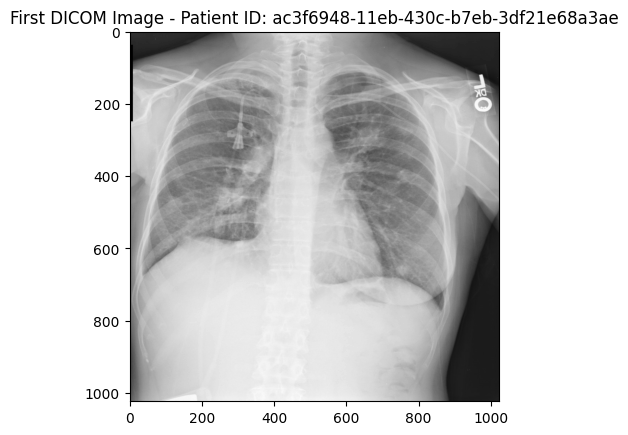

In [ ]:
#Lets see first image from our train_images dataset
if not trainImageData_df.empty:
    plt.imshow(trainImageData_df.iloc[0]['Image'], cmap='gray')
    plt.title(f"First DICOM Image - Patient ID: {trainImageData_df.iloc[0]['patient_id']}")
    plt.show()
else:
    print("No images loaded")

#### Testing Images

In [ ]:
data_folder = '/content/drive/MyDrive/stage_2_test_images'
test_images = load_dicom_images_in_batches(data_folder)

In [ ]:
test_images.shape

In [ ]:
test_images.info()

In [ ]:
test_images.sample(5)

In [ ]:
if not test_images.empty:
    plt.imshow(test_images.iloc[0]['image'], cmap='gray')
    plt.title(f"First DICOM Image - Patient ID: {test_images.iloc[0]['patient_id']}")
    plt.show()
else:
    print("No images loaded")

## Combining datasets

In [ ]:
train_labels.rename(columns={'patientId': 'patient_id'}, inplace=True)
train_image_csv.rename(columns={'Patient ID': 'patient_id'}, inplace=True)
trainImageData_df.rename(columns={'patient_id': 'patient_id'}, inplace=True)

In [ ]:
train_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  30227 non-null  object 
 1   x           9555 non-null   float64
 2   y           9555 non-null   float64
 3   width       9555 non-null   float64
 4   height      9555 non-null   float64
 5   Target      30227 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 1.4+ MB


In [ ]:
combined_df = trainImageData_df.merge(train_labels[['patient_id', 'Target']], on='patient_id', how='left')

In [ ]:
final_dataset = combined_df.merge(train_image_csv[['patient_id', 'Age', 'Gender']], on='patient_id', how='left')

In [ ]:
final_dataset = final_dataset[['patient_id', 'Age', 'Gender', 'Image', 'Target']]

In [ ]:
final_dataset.sample(5)

,patient_id,Age,Gender,Image,Target
19822,3211c41c-8ced-42ba-8b0f-a04797f1ff27,57,F,"[[2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2,...",1
2105,731bc722-4bd2-4d18-91c0-e9adfcfffa98,8,M,"[[255, 255, 254, 255, 255, 255, 255, 254, 255,...",0
25019,7342f4bc-2ce8-4d13-b820-7d90f8804a1b,33,M,"[[2, 2, 2, 2, 2, 2, 3, 3, 1, 1, 1, 1, 1, 1, 1,...",1
19342,9960c058-8c83-46c9-b311-5dd7e927eb34,61,M,"[[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,...",1
2496,515ab870-a80e-47f1-bd51-05a6fc02cba0,54,F,"[[28, 26, 15, 13, 15, 13, 13, 12, 14, 15, 14, ...",1


In [ ]:
final_dataset.shape

(30227, 5)

In [ ]:
final_dataset['patient_id'].duplicated().sum()

3543

In [ ]:
#Remove duplicate patient IDs from the data set
final_dataset.drop_duplicates(subset='patient_id', keep='first',inplace=True)

In [ ]:
final_dataset.shape

(26684, 5)

# Data preprocessing and visualisation

## Map annotations to images

In [ ]:
def map_annotations(labels_df):
    annotations = {}
    for _, row in labels_df.iterrows():
        patient_id = row['patient_id']
        if patient_id not in annotations:
            annotations[patient_id] = []

        annotations[patient_id].append({
            'x': row['x'],
            'y': row['y'],
            'width': row['width'],
            'height': row['height'],
            'target': row['Target']
        })
    return annotations

In [ ]:
train_annotations = map_annotations(train_labels)

In [ ]:
sample_keys = list(train_annotations.keys())[:5]
for patient_id in sample_keys:
    print(f"Patient ID: {patient_id}")
    for annotation in train_annotations[patient_id]:
        print(f"  Annotation: x={annotation['x']}, y={annotation['y']}, width={annotation['width']}, height={annotation['height']}, target={'Pneumonia' if annotation['target'] == 1 else 'Normal'}")
    print()

Patient ID: 0004cfab-14fd-4e49-80ba-63a80b6bddd6
  Annotation: x=nan, y=nan, width=nan, height=nan, target=Normal

Patient ID: 00313ee0-9eaa-42f4-b0ab-c148ed3241cd
  Annotation: x=nan, y=nan, width=nan, height=nan, target=Normal

Patient ID: 00322d4d-1c29-4943-afc9-b6754be640eb
  Annotation: x=nan, y=nan, width=nan, height=nan, target=Normal

Patient ID: 003d8fa0-6bf1-40ed-b54c-ac657f8495c5
  Annotation: x=nan, y=nan, width=nan, height=nan, target=Normal

Patient ID: 00436515-870c-4b36-a041-de91049b9ab4
  Annotation: x=264.0, y=152.0, width=213.0, height=379.0, target=Pneumonia
  Annotation: x=562.0, y=152.0, width=256.0, height=453.0, target=Pneumonia



In [ ]:
# Add the annotations to the final dataset
final_dataset['annotations'] = final_dataset['patient_id'].map(train_annotations)

In [ ]:
final_dataset.head()

,patient_id,Age,Gender,Image,Target,annotations
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,51,F,"[[144, 128, 114, 105, 94, 82, 72, 66, 59, 54, ...",0,"[{'x': nan, 'y': nan, 'width': nan, 'height': ..."
1,000db696-cf54-4385-b10b-6b16fbb3f985,25,F,"[[1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,...",1,"[{'x': 316.0, 'y': 318.0, 'width': 170.0, 'hei..."
2,000db696-cf54-4385-b10b-6b16fbb3f985,25,F,"[[1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,...",1,"[{'x': 316.0, 'y': 318.0, 'width': 170.0, 'hei..."
3,000fe35a-2649-43d4-b027-e67796d412e0,40,M,"[[1, 10, 9, 9, 10, 9, 10, 9, 9, 10, 10, 10, 10...",1,"[{'x': 570.0, 'y': 282.0, 'width': 269.0, 'hei..."
4,000fe35a-2649-43d4-b027-e67796d412e0,40,M,"[[1, 10, 9, 9, 10, 9, 10, 9, 9, 10, 10, 10, 10...",1,"[{'x': 570.0, 'y': 282.0, 'width': 269.0, 'hei..."


## Visualize annotations

In [ ]:
def visualize_and_save_annotations(patient_ids, annotations, train_images_df, save_dir='/content/drive/MyDrive/Images/annotated_images'):
    os.makedirs(save_dir, exist_ok=True)

    for patient_id in patient_ids:
        img_row = train_images_df[train_images_df['patient_id'] == patient_id]

        if img_row.empty:
            print(f"No image found for patient ID {patient_id}")
            continue

        img_data = img_row.iloc[0]['Image']
        img = np.array(img_data)

        # Convert to grayscale if the image is not already in that format
        if len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        for annotation in annotations.get(patient_id, []):
            if not pd.isna(annotation['x']):
                start_point = (int(annotation['x']), int(annotation['y']))
                end_point = (int(annotation['x'] + annotation['width']), int(annotation['y'] + annotation['height']))
                color = (255, 0, 0)  # Red color for bounding box
                thickness = 2
                img = cv2.rectangle(img, start_point, end_point, color, thickness)

            target_label = 'Pneumonia' if annotation['target'] == 1 else 'Normal'

        plt.figure(figsize=(10, 10))
        plt.imshow(img, cmap='gray')
        plt.title(f"Annotations for patient ID {patient_id}")
        plt.figtext(0.5, 0.01, f"{target_label}", ha='center', va='center')
        plt.axis('off')

        # Save the image
        file_name = os.path.join(save_dir, f"{patient_id}.png")
        plt.savefig(file_name, bbox_inches='tight', pad_inches=0)
        plt.show()


In [ ]:
pneumonia_patient_ids = final_dataset[final_dataset['Target'] == 1]['patient_id'].sample(5).tolist()
normal_patient_ids = final_dataset[final_dataset['Target'] == 0]['patient_id'].sample(5).tolist()

Visualizing images with target 1 (Pneumonia):


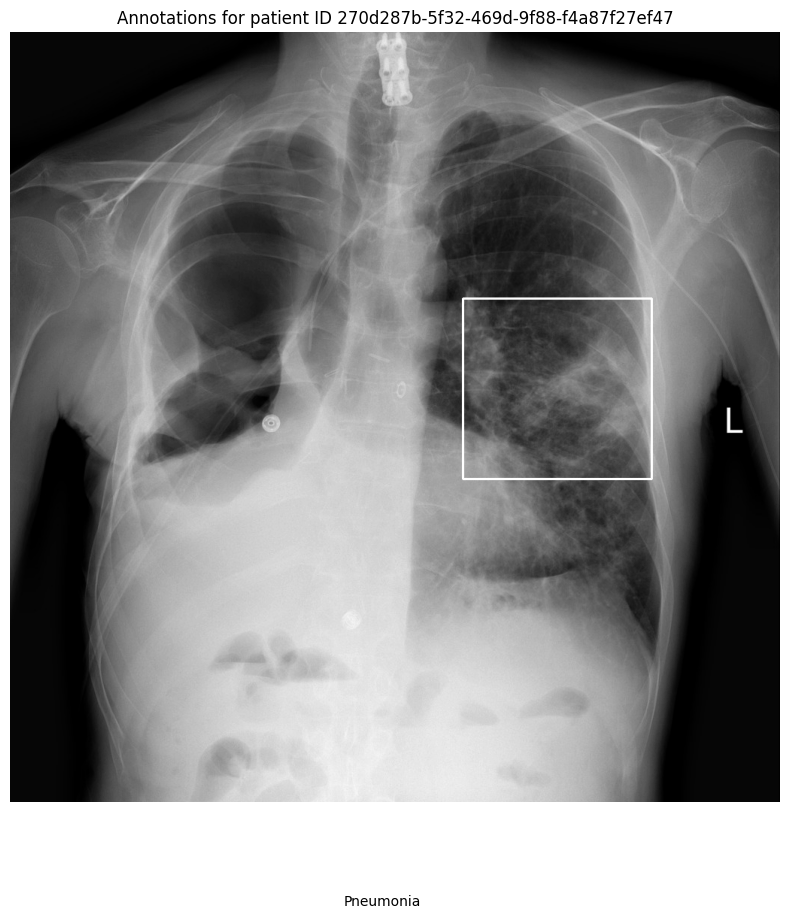

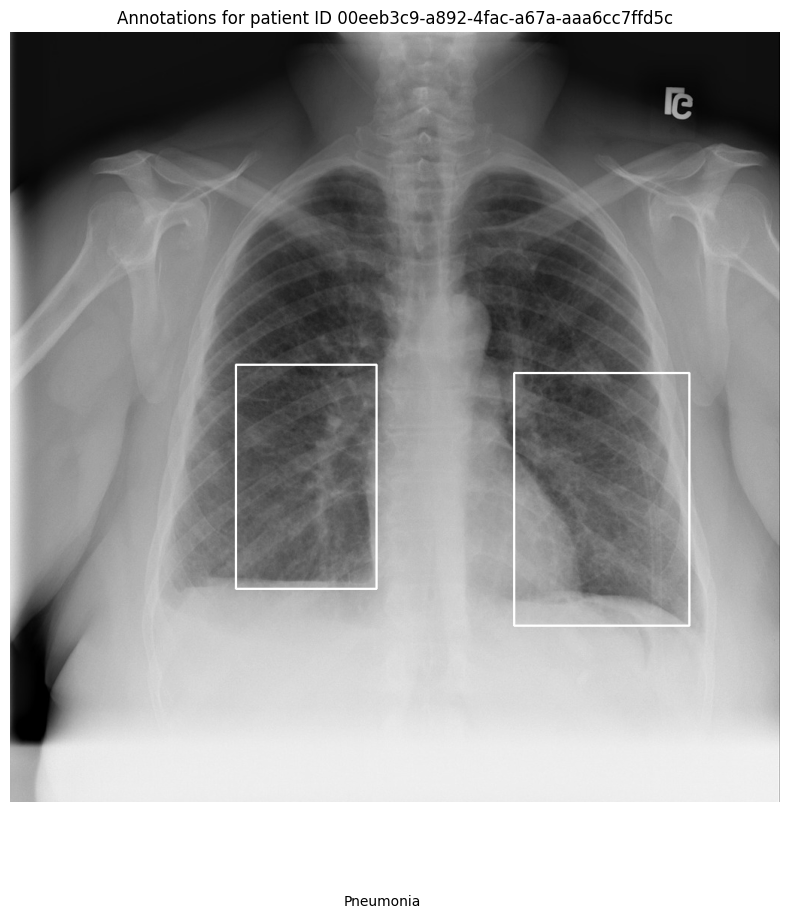

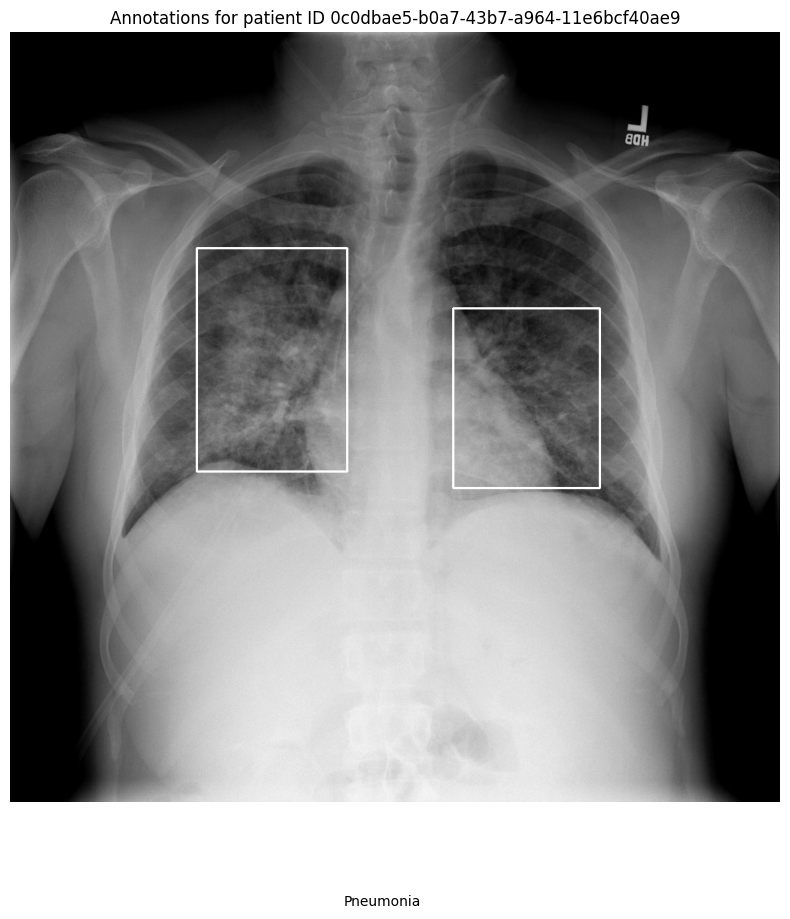

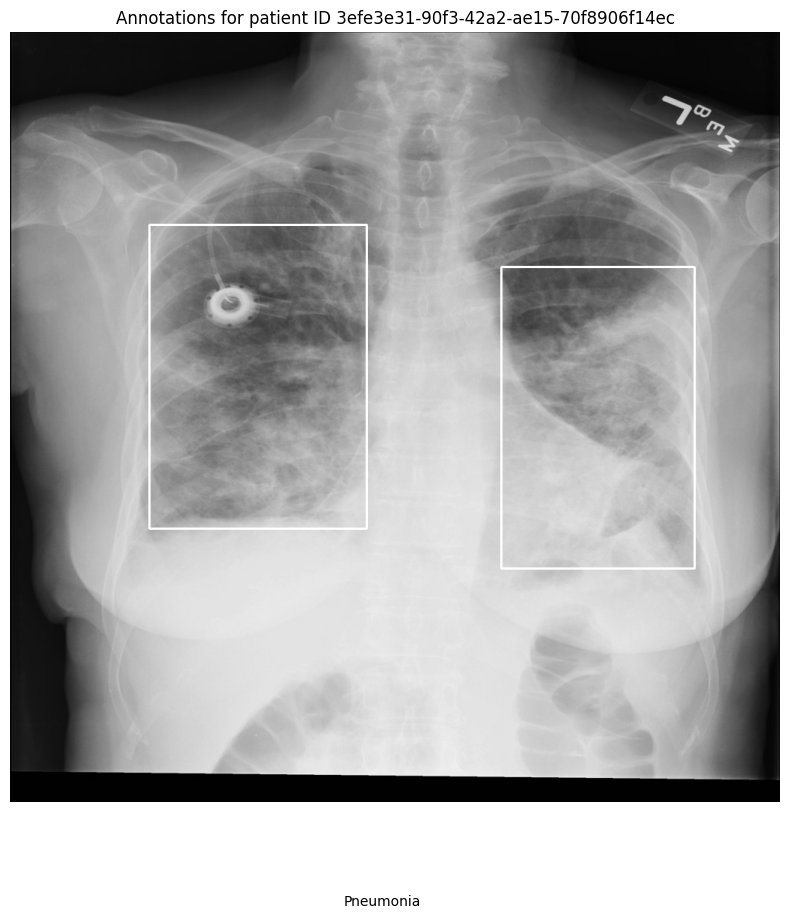

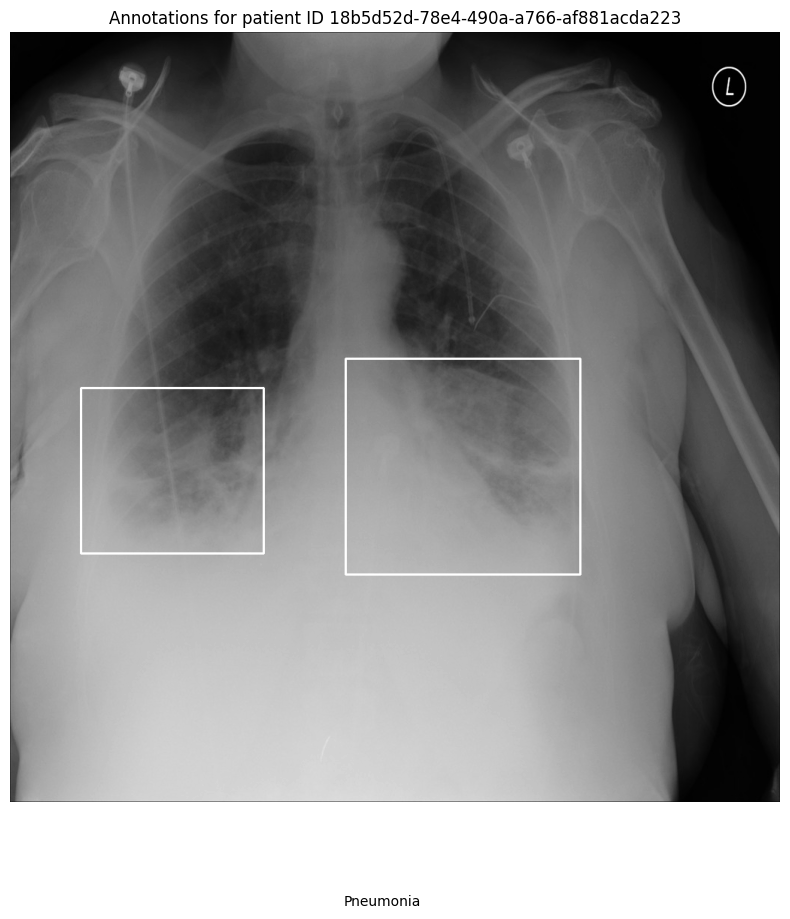

In [ ]:
print("Visualizing images with target 1 (Pneumonia):")
visualize_and_save_annotations(pneumonia_patient_ids, train_annotations, final_dataset)

Visualizing images with target 0 (Normal):


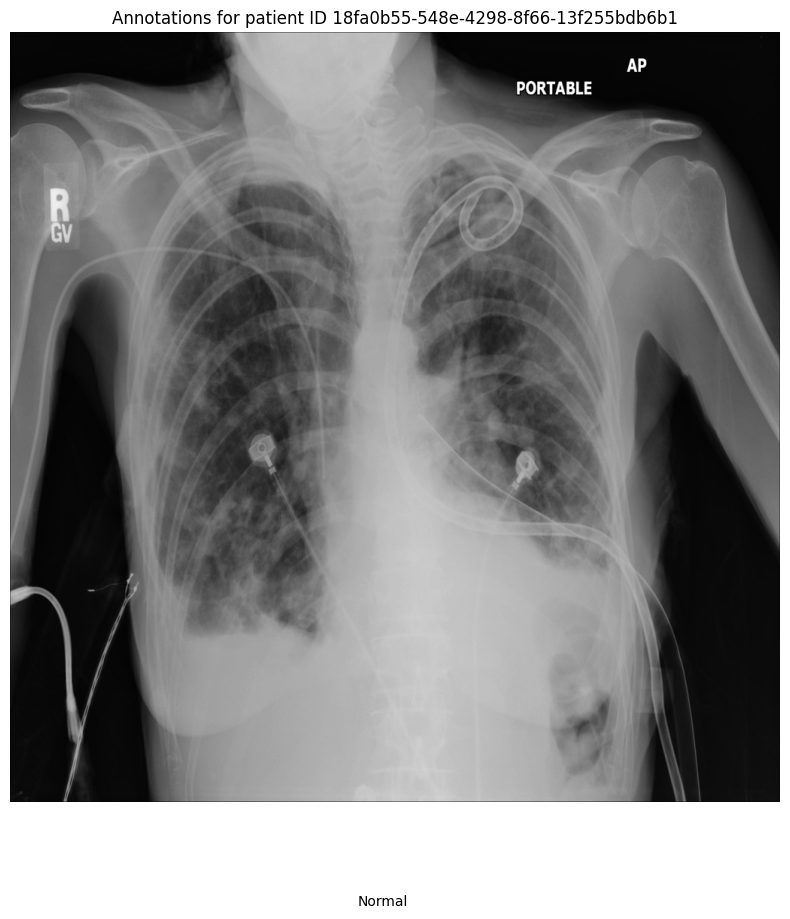

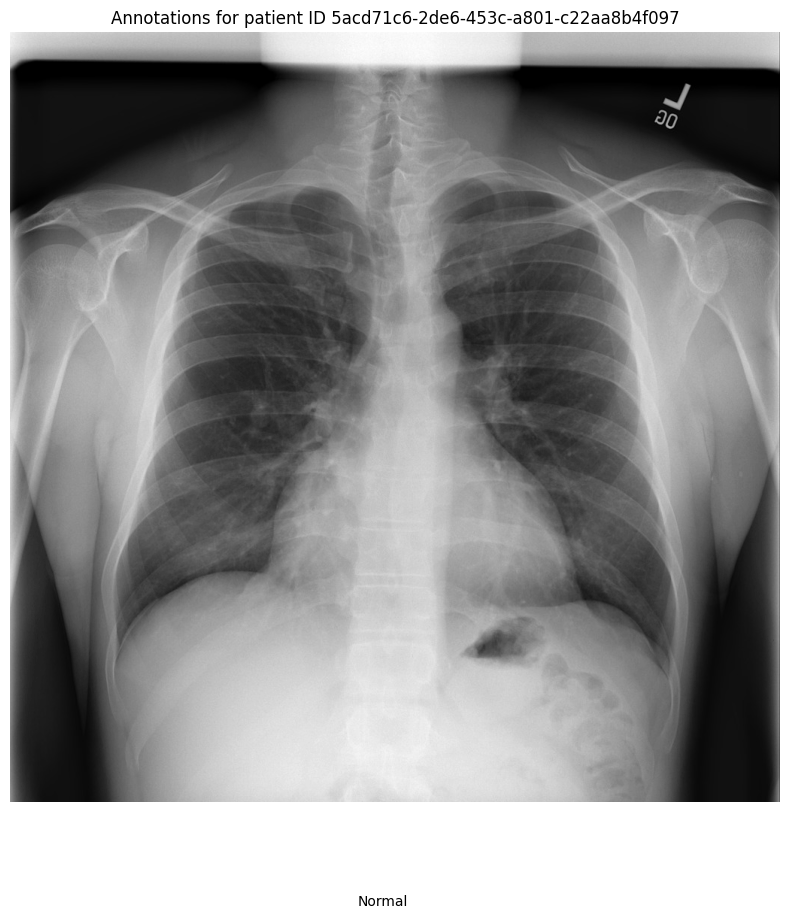

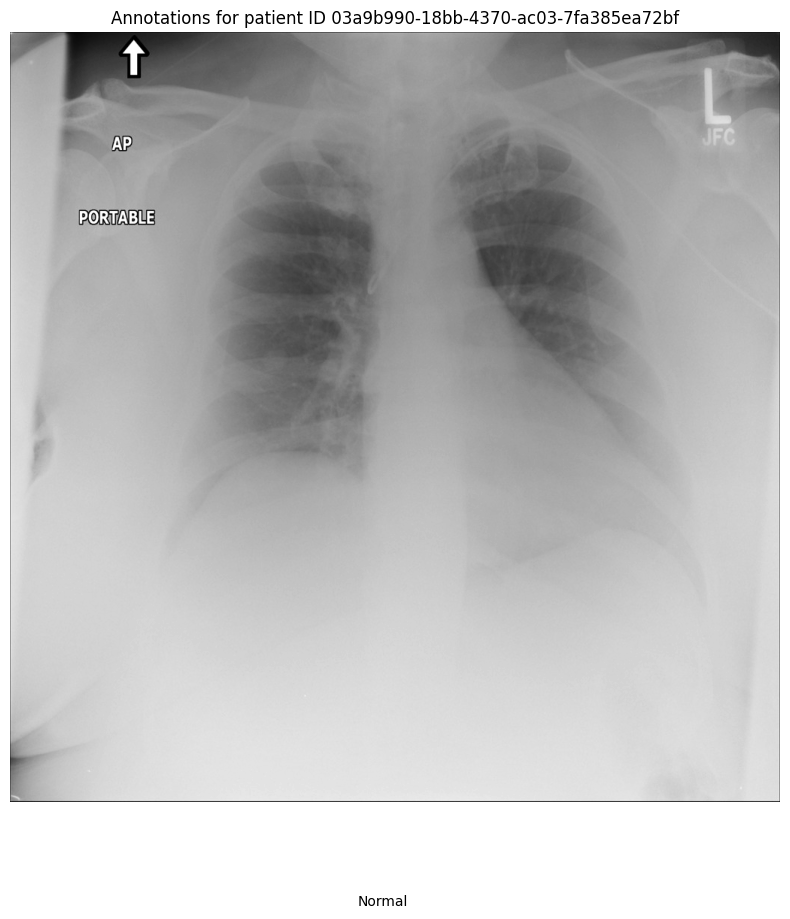

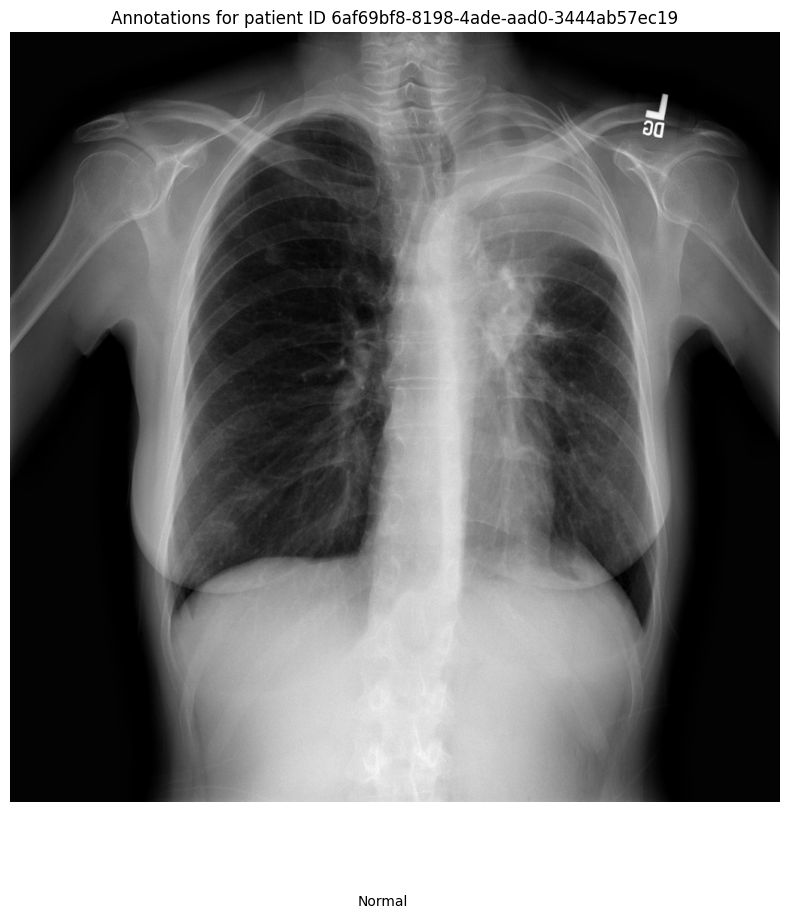

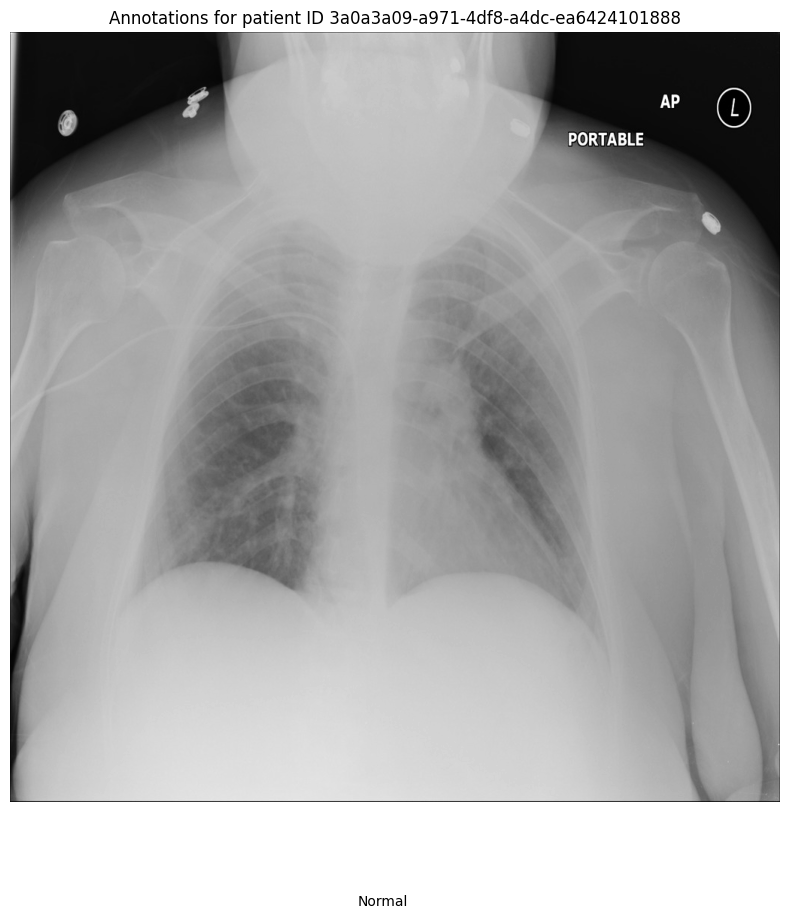

In [ ]:
print("Visualizing images with target 0 (Normal):")
visualize_and_save_annotations(normal_patient_ids, train_annotations, final_dataset)

## Univariant Analysis

### Target Distribution

In [ ]:
unique_patientId = train_labels.drop_duplicates(subset = ['patient_id'])

In [ ]:
target = (
    unique_patientId['Target']
    .value_counts()
    .to_frame()
    .reset_index()
    .replace({0: 'Normal', 1: 'Pneumonia'})
    .groupby('Target')
    .sum()
    .reset_index()
)

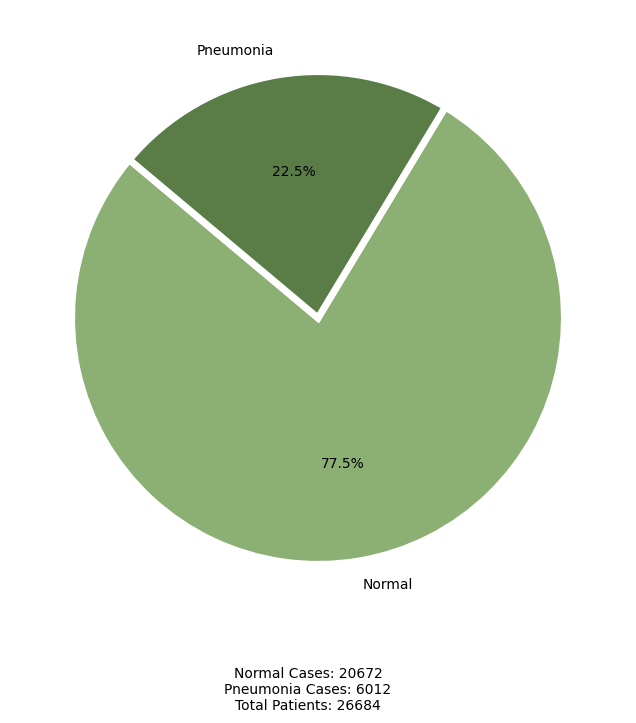

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(target['count'], labels=target['Target'], colors=['#8cb074', '#5a7c47'],
        autopct='%1.1f%%', startangle=140, wedgeprops={'linewidth': 5, 'edgecolor': 'white'})
plt.figtext(0.5, 0.01, f"Total Patients: {len(unique_patientId)}", ha='center', va='center')
pneumonia_cases = target[target['Target'] == 'Pneumonia']['count'].values[0]
normal_cases = target[target['Target'] == 'Normal']['count'].values[0]
plt.figtext(0.5, 0.03, f"Pneumonia Cases: {pneumonia_cases}", ha='center', va='center')
plt.figtext(0.5, 0.05, f"Normal Cases: {normal_cases}", ha='center', va='center')

plt.savefig('/content/drive/MyDrive/Images/target_distribution_pie_chart.png')

plt.show()

**_Insights:_**
* Overall 26684 patient x-ray images are available for pneumonia detection.

* Number of pneumonia cases in the dataset are 6012, which is around 22.5% of total cases.

* Number of Normal cases in the dataset are 20672, which is around 77.5% of total cases.

### Other Distributions

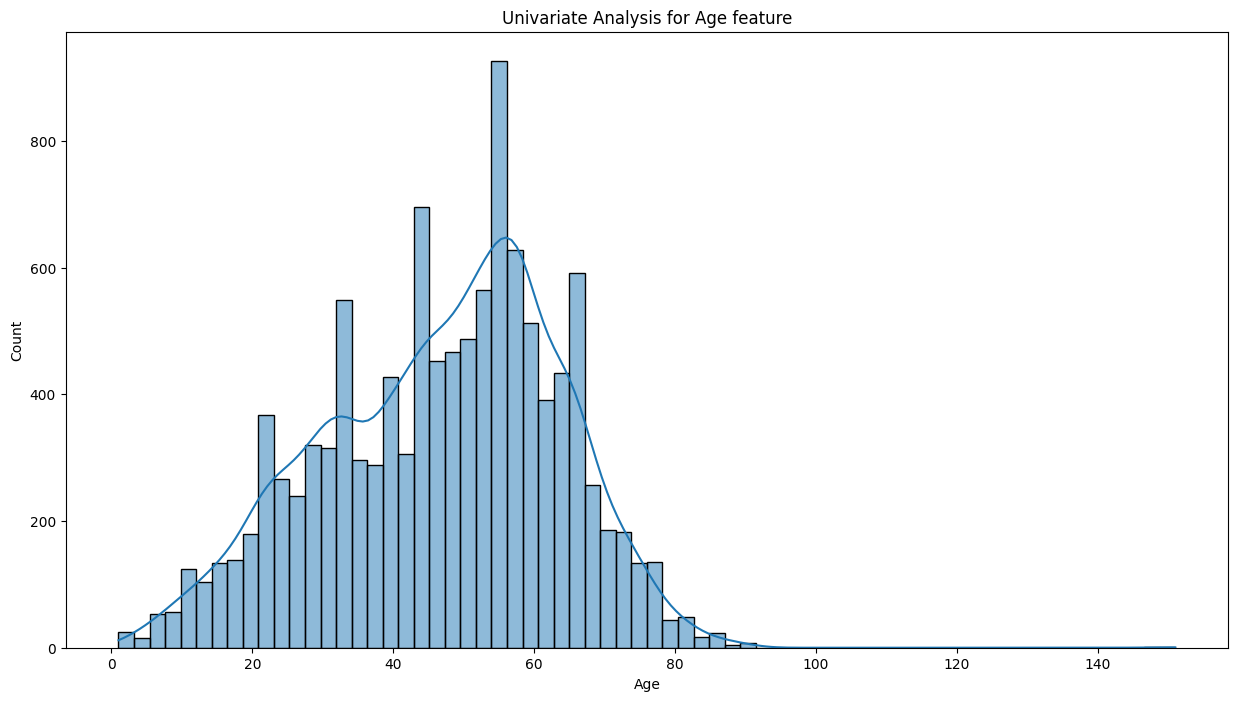

In [ ]:
plt.figure(figsize=(15,8))

sns.histplot(final_dataset, x="Age",kde='True')
plt.title('Univariate Analysis for Age feature')
plt.xlabel('Age')
plt.show()

* We can see uniform distribution of age parameter across our data sample

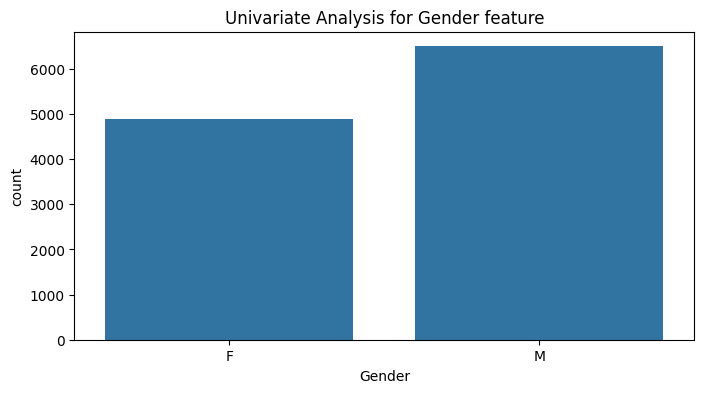

In [ ]:
plt.figure(figsize=(8,4))

sns.countplot(final_dataset, x="Gender")
plt.title('Univariate Analysis for Gender feature')
plt.xlabel('Gender')
plt.show()

## Bivariant Analysis

In [ ]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
age_labels = [f'{i}-{i+9}' for i in range(0, 100, 10)]
final_dataset['age_group'] = pd.cut(final_dataset['Age'], bins=age_bins, labels=age_labels, right=False)

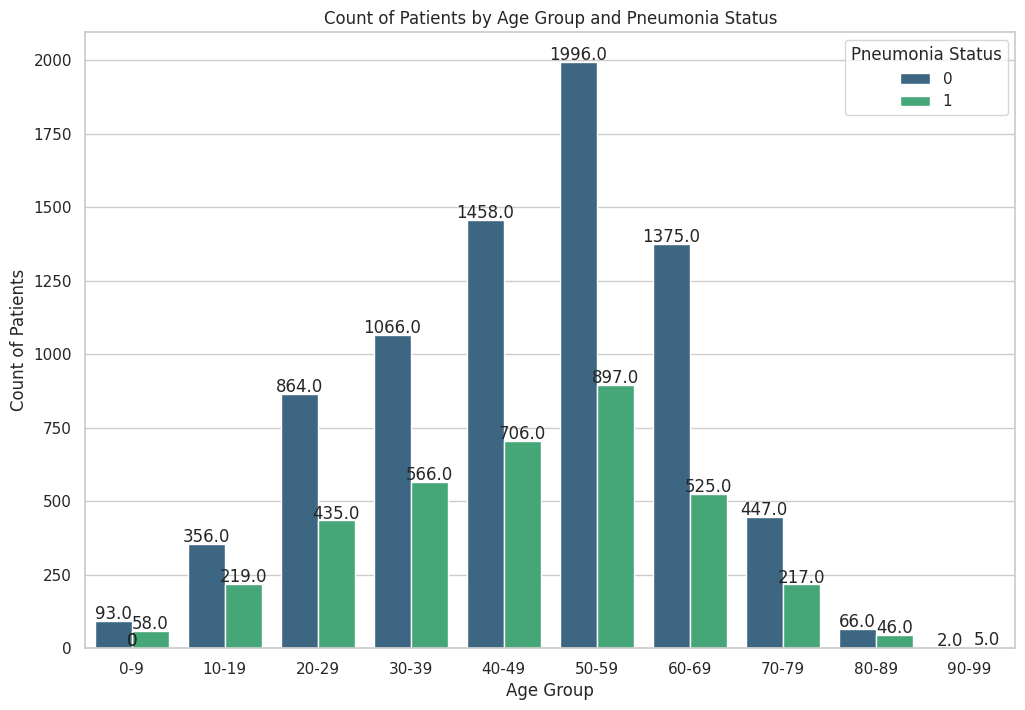

In [ ]:
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

barplot = sns.countplot(x='age_group', hue='Target', data=final_dataset, palette="viridis")

for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{height}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha = 'center', va = 'center',
                     xytext = (0, 5),
                     textcoords = 'offset points')

plt.title("Count of Patients by Age Group and Pneumonia Status")
plt.xlabel("Age Group")
plt.ylabel("Count of Patients")
plt.legend(title="Pneumonia Status", loc='upper right')

plt.savefig('/content/drive/MyDrive/Images/Age_distribution_with_Pneumonia_Status.png')

plt.show()

**_Insights_**
* Highest count of pneumonia cases belongs to age group of 50 to 60.
* Highest number pneumonia cases belongs to age group of 30 to 70 which comes around 60%-70% of overall cases.
* Least number of pneumonia  case reported for age group of >20 & <70.

In [ ]:
fig = px.histogram(final_dataset,
                   x="Gender",
                   color="Target",
                   barmode="stack",
                   title="Distribution of Pneumonia by Gender",
                   labels={"target": "Pneumonia Status", "gender": "Gender"},
                   category_orders={"gender": ["Male", "Female"]},
                   text_auto=True)
fig.update_layout(yaxis_title="Count")
fig.show()

**_Insights_**
* Blue colour indicates if the patient is normal and by red colour indicates that patient has pneumonia.
* As per below statics that male are more prone to have pneumonia.
 - Female pneumonia cases identified around 1497.
 - Male pneumonia cases identified around 2177

## Multivariant Analysis

In [ ]:
final_dataset['Gender'] = final_dataset['Gender'].astype('category').cat.codes

In [ ]:
corr = final_dataset[['Gender', 'Age', 'Target']].corr()

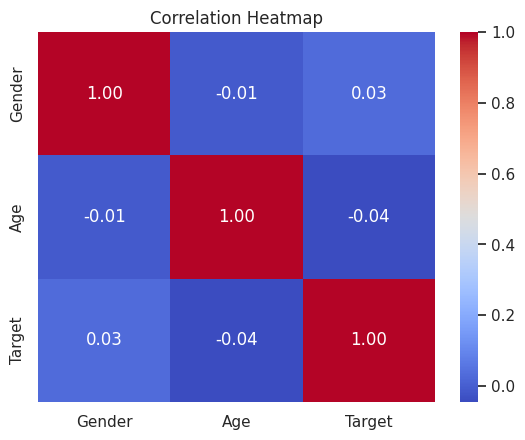

In [ ]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Image Preprocessing

In [ ]:
def get_transform():
    return A.Compose([
        A.Resize(224, 224),
        A.ToFloat(always_apply=True, max_value=255.0),
        A.HorizontalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.MotionBlur(p=0.2),
        A.MedianBlur(blur_limit=3, p=0.1),
        A.Blur(blur_limit=3, p=0.1),
        ToTensorV2(p=1.0)
    ])

In [ ]:
def load_image_from_array(array):
    return Image.fromarray(np.array(array))

In [ ]:
def apply_transformations(images, transform):
    transformed_images = []
    for img in images:
        img = np.array(img)
        augmented = transform(image=img)
        transformed_images.append(augmented['image'])
    return transformed_images

In [ ]:
# Split the dataset as train data and test data(10%)
# train_df_init: used for Training the model
# test_df: used to test the model for performance metrics as unseeen data
train_df_init, test_df = train_test_split(
    final_dataset,
    test_size=0.1,
    stratify=final_dataset['Target'],
    random_state=42
)

In [ ]:
# The train dataset is again splitted as train and test data set for training the model
train_df, valid_df = train_test_split(
    train_df_init,
    test_size=0.1,
    stratify=train_df_init['Target'],
    random_state=42
)

In [ ]:
# Train and validation Data
X_train = [load_image_from_array(img) for img in train_df['Image']]
y_train = train_df['Target'].values

X_val = [load_image_from_array(img) for img in valid_df['Image']]
y_val = valid_df['Target'].values

In [ ]:
#Test Data
X_test = [load_image_from_array(img) for img in test_df['Image']]
y_test = test_df['Target'].values

In [ ]:
print("X_train shape:", len(X_train))
print("Y_train shape:", len(y_train))
print('--'*25)
print("X_val shape:", len(X_val))
print("Y_val shape:", len(y_val))
print('--'*25)
print("X_test shape:", len(X_test))
print("Y_test shape:", len(y_test))
print('--'*25)

X_train shape: 21613
Y_train shape: 21613
--------------------------------------------------
X_val shape: 2402
Y_val shape: 2402
--------------------------------------------------
X_test shape: 2669
Y_test shape: 2669
--------------------------------------------------


In [ ]:
X_train_transformed = apply_transformations(X_train, get_transform())
X_valid_transformed = apply_transformations(X_val, get_transform())
X_test_transformed = apply_transformations(X_test, get_transform())

In [ ]:
X_train_transformed = np.squeeze(X_train_transformed, axis=1)
X_valid_transformed = np.squeeze(X_valid_transformed, axis=1)
X_test_transformed = np.squeeze(X_test_transformed, axis=1)

# Add channel dimension
X_train_transformed = np.expand_dims(X_train_transformed, axis=-1)
X_valid_transformed = np.expand_dims(X_valid_transformed, axis=-1)
X_test_transformed = np.expand_dims(X_test_transformed, axis=-1)

In [ ]:
print(f"Shape of X_train_transformed after squeeze: {X_train_transformed.shape}")
print(f"Shape of X_valid_transformed after squeeze: {X_valid_transformed.shape}")
print(f"Shape of X_test_transformed after squeeze: {X_test_transformed.shape}")

Shape of X_train_transformed after squeeze: (21613, 224, 224, 1)
Shape of X_valid_transformed after squeeze: (2402, 224, 224, 1)
Shape of X_test_transformed after squeeze: (2669, 224, 224, 1)


In [ ]:
def convert_to_rgb(images):
    # Convert NumPy array to TensorFlow tensor
    images_tensor = tf.convert_to_tensor(images, dtype=tf.float32)
    # Convert grayscale images to RGB by duplicating the single channel
    images_rgb = tf.image.grayscale_to_rgb(images_tensor)
    return images_rgb

In [ ]:
X_train_rgb = convert_to_rgb(X_train_transformed)
X_valid_rgb = convert_to_rgb(X_valid_transformed)
X_test_rgb = convert_to_rgb(X_test_transformed)

In [ ]:
print(f'Shape of X_train_rgb: {X_train_rgb.shape}')
print(f'Shape of X_valid_rgb: {X_valid_rgb.shape}')
print(f'Shape of X_test_rgb: {X_test_rgb.shape}')

Shape of X_train_rgb: (21613, 224, 224, 3)
Shape of X_valid_rgb: (2402, 224, 224, 3)
Shape of X_test_rgb: (2669, 224, 224, 3)


# Model Building

## Base Model

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(300, 300, 1), padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 300, 300, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 150, 150, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 150, 150, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 75, 75, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 37, 37, 128)       0

In [ ]:
optimizer = tf.keras.optimizers.Adam(0.001)
cnn_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-6
)

In [ ]:
cnn_model.fit(
    X_train_transformed,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_valid_transformed, np.array(y_valid)),
    callbacks=[early_stopping,reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/10
321/321 [==============================] - 267s 827ms/step - loss: 7.7046 - accuracy: 0.5995 - val_loss: 0.6252 - val_accuracy: 0.6281 - lr: 0.0010
Epoch 2/10
321/321 [==============================] - 264s 824ms/step - loss: 0.6309 - accuracy: 0.6336 - val_loss: 0.6517 - val_accuracy: 0.6088 - lr: 0.0010
Epoch 3/10
321/321 [==============================] - 264s 822ms/step - loss: 0.5725 - accuracy: 0.6887 - val_loss: 0.6516 - val_accuracy: 0.6465 - lr: 0.0010
Epoch 4/10
321/321 [==============================] - 264s 821ms/step - loss: 0.4789 - accuracy: 0.7553 - val_loss: 0.7319 - val_accuracy: 0.6482 - lr: 0.0010
Epoch 5/10
321/321 [==============================] - 263s 821ms/step - loss: 0.3336 - accuracy: 0.8523 - val_loss: 0.7870 - val_accuracy: 0.6711 - lr: 1.0000e-04
Epoch 6/10
321/321 [==============================] - 264s 822ms/step - loss: 0.2799 - accuracy: 0.8833 - val_loss: 0.8876 - val_accuracy: 0.6746 - lr: 1.0000e-04


In [ ]:
history = cnn_model.history

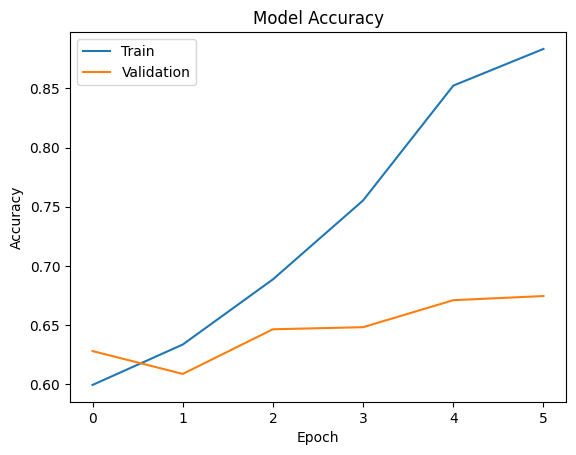

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('/content/drive/MyDrive/Images/Model_Accuracy_my_base_cnn_model.png')
plt.show()

In [ ]:
pickle_file_path='/content/drive/MyDrive/my_base_cnn_model.pkl'
with open(pickle_file_path, 'wb') as file:
    pickle.dump(cnn_model, file)

In [ ]:
predictions = cnn_model.predict(X_valid_transformed)

predicted_classes = (predictions > 0.5).astype("int32")

36/36 [==============================] - 5s 150ms/step


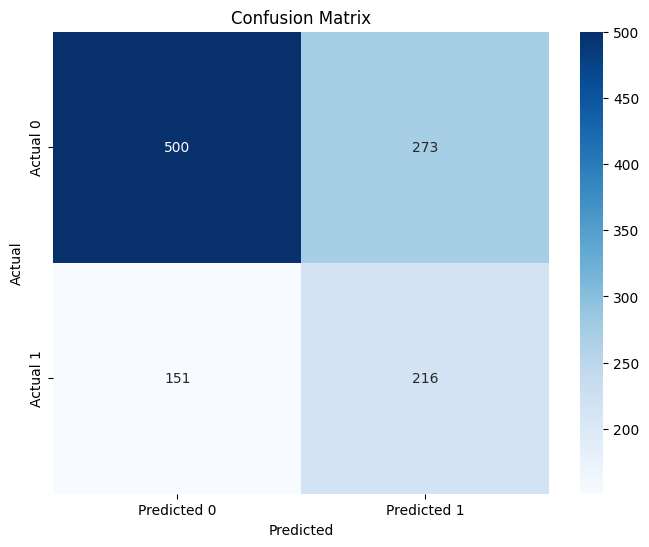

In [ ]:
cm = confusion_matrix(np.array(y_valid), predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/Images/Confusion_Matrix_my_base_cnn_model.png')
plt.show()

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(np.array(y_valid), predicted_classes)

# Calculate precision
precision = precision_score(np.array(y_valid), predicted_classes)

# Calculate recall
recall = recall_score(np.array(y_valid), predicted_classes)

# Calculate F1 score
f1 = f1_score(np.array(y_valid), predicted_classes)

In [ ]:
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.6281
Precision: 0.4417
Recall: 0.5886
F1 Score: 0.5047


In [ ]:
#Create a data frame to lsit down all the results
df_results=pd.DataFrame({'Model_Name':' Base Model','Accuracy':accuracy,'Precision':precision,'Recall':recall,'F1_Score': f1},index=[0])
df_results

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,Base Model,0.6281,0.4417,0.5886,0.5047


## Base Model with L2 Regularization

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
cnn_model_with_l2 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(300, 300, 1), padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
cnn_model_with_l2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 300, 300, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 150, 150, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 150, 150, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 75, 75, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 37, 37, 128)       0

In [ ]:
optimizer = tf.keras.optimizers.Adam(0.001)
cnn_model_with_l2.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-6
)

In [ ]:
checkpoint_path = '/content/drive/MyDrive/cnn_model_with_l2_checkpoint.h5'

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

In [ ]:
cnn_model_with_l2.fit(
    X_train_transformed,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_valid_transformed, np.array(y_valid)),
    callbacks=[checkpoint_callback, early_stopping, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/10
321/321 [==============================] - ETA: 0s - loss: 13.7066 - accuracy: 0.6319
Epoch 1: val_loss improved from inf to 0.66630, saving model to /content/drive/MyDrive/cnn_model_with_l2_checkpoint.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


321/321 [==============================] - 287s 891ms/step - loss: 13.7066 - accuracy: 0.6319 - val_loss: 0.6663 - val_accuracy: 0.7237 - lr: 0.0010
Epoch 2/10
321/321 [==============================] - ETA: 0s - loss: 0.6684 - accuracy: 0.7245
Epoch 2: val_loss did not improve from 0.66630
321/321 [==============================] - 286s 891ms/step - loss: 0.6684 - accuracy: 0.7245 - val_loss: 0.6938 - val_accuracy: 0.7211 - lr: 0.0010
Epoch 3/10
321/321 [==============================] - ETA: 0s - loss: 0.5998 - accuracy: 0.7829
Epoch 3: val_loss did not improve from 0.66630
321/321 [==============================] - 286s 892ms/step - loss: 0.5998 - accuracy: 0.7829 - val_loss: 0.7060 - val_accuracy: 0.7395 - lr: 0.0010
Epoch 4/10
321/321 [==============================] - ETA: 0s - loss: 0.5257 - accuracy: 0.8339
Epoch 4: val_loss did not improve from 0.66630
321/321 [==============================] - 287s 894ms/step - loss: 0.5257 - accuracy: 0.8339 - val_loss: 0.8798 - val_accuracy

In [ ]:
pickle_file_path='/content/drive/MyDrive/cnn_model_with_l2.pkl'
with open(pickle_file_path, 'wb') as file:
    pickle.dump(cnn_model_with_l2, file)

In [ ]:
history = cnn_model_with_l2.history

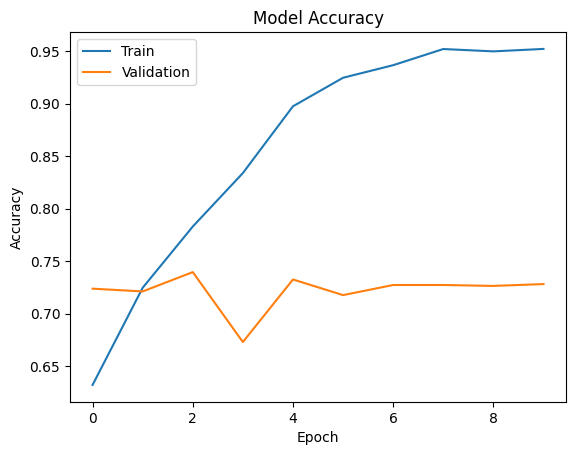

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('/content/drive/MyDrive/Images/Model_Accuracy_cnn_model_with_l2.png')
plt.show()

In [ ]:
predictions = cnn_model_with_l2.predict(X_valid_transformed)

predicted_classes = (predictions > 0.5).astype("int32")

36/36 [==============================] - 6s 158ms/step


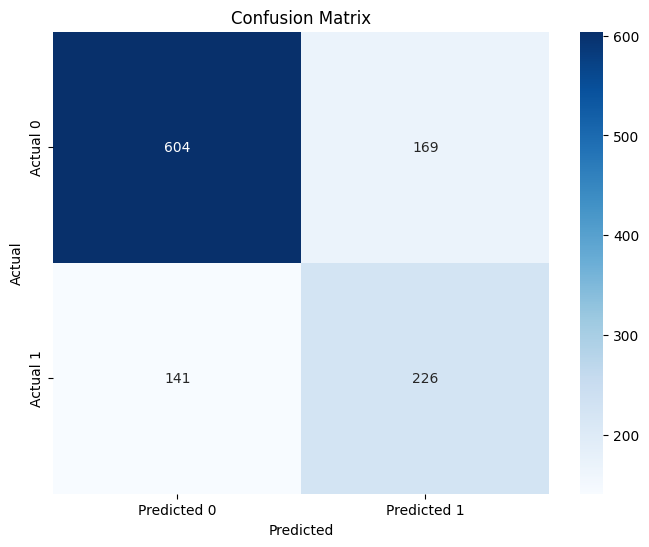

In [ ]:
cm = confusion_matrix(np.array(y_valid), predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/Images/Confusion_Matrix_cnn_model_with_l2.png')
plt.show()

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(np.array(y_valid), predicted_classes)

# Calculate precision
precision = precision_score(np.array(y_valid), predicted_classes)

# Calculate recall
recall = recall_score(np.array(y_valid), predicted_classes)

# Calculate F1 score
f1 = f1_score(np.array(y_valid), predicted_classes)

In [ ]:
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.7281
Precision: 0.5722
Recall: 0.6158
F1 Score: 0.5932


In [ ]:
new_row_index = len(df_results)
df_results.loc[new_row_index] = ['Base_Model_with_l2',accuracy,precision,recall,f1]
df_results

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,Base Model,0.6281,0.4417,0.5886,0.5047
1,Base_Model_with_l2,0.7281,0.5722,0.6158,0.5932


## CNN with Data Augmentation

In [ ]:
global itr
itr=0
def resize_img(img,target_size=(300,300)):
  global itr

  img=cv2.resize(img,target_size)
  if img.shape != target_size :
    itr=itr+1
  img=np.expand_dims(img,axis=-1)
  img = img.astype('float32') / 255.0

  return np.array(img)

In [ ]:
X_train_scaled=train_df['Image'].apply(resize_img)
X_test_scaled=test_df['Image'].apply(resize_img)

In [ ]:
X_train_scaled[0].shape

(300, 300, 1)

In [ ]:
y_train = train_df['Target'].values
y_test = test_df['Target'].values

In [ ]:
backend.clear_session()

In [ ]:
# Convert X_train_scaled to a NumPy array with the correct shape
X_train_scaled_1 = np.array([np.array(x).astype('float32') for x in X_train_scaled])
Y_train_1 = np.array(y_train).astype('float32')  # This line was likely correct

In [ ]:
# Convert X_train_scaled to a NumPy array with the correct shape
X_test_scaled_1 = np.array([np.array(x).astype('float32') for x in X_test_scaled])
Y_test_1 = np.array(y_test).astype('float32')  # This line was likely correct

In [ ]:
print(f'shape of X_train_scaled_1:{X_train_scaled_1.shape}')
print(f'shape of Y_train_1:{Y_train_1.shape}')

shape of X_train_scaled_1:(10259, 300, 300, 1)
shape of Y_train_1:(10259,)


In [ ]:
# Defining the data generator for augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Split for validation
)

# Fit the generator on the training data
datagen.fit(X_train_scaled_1)

# Create training and validation generators
train_generator = datagen.flow(X_train_scaled_1, Y_train_1, batch_size=32, subset='training')
validation_generator = datagen.flow(X_train_scaled_1, Y_train_1, batch_size=32, subset='validation')

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train_1),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: 0.7378452243958573, 1: 1.5511037193831267}


In [ ]:
backend.clear_session()

In [ ]:
#Function to create the model
def create_cnn_model_1(input_shape=(300, 300, 1)):
    model = Sequential([
        Conv2D(64, (3, 3), activation='relu', input_shape=input_shape, kernel_initializer='he_uniform',padding='same'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_uniform',padding='same'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(256, (3, 3), activation='relu',kernel_initializer='he_uniform',padding='same'),
        MaxPooling2D(pool_size=(2, 2)),


        Flatten(),

        Dense(512, activation='relu'),
        BatchNormalization(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    model.compile(optimizer='adam',
                  loss=keras.losses.binary_crossentropy,
                  metrics=['accuracy'])
    return model

# Create the model
model_1 = create_cnn_model_1()
model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 300, 300, 64)      640       
                                                                 
 max_pooling2d (MaxPooling2  (None, 150, 150, 64)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 150, 150, 128)     73856     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 75, 75, 128)       0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 256)       295168    
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 37, 37, 256)       0

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-6
)

In [ ]:
#Fit the model
epoch=15

history_1 = model_1.fit(
    train_generator,
    epochs=epoch,
    validation_data=validation_generator,
    callbacks=[early_stopping,reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/15
257/257 [==============================] - 521s 2s/step - loss: 0.6601 - accuracy: 0.6289 - val_loss: 0.7576 - val_accuracy: 0.5792 - lr: 0.0010
Epoch 2/15
257/257 [==============================] - 524s 2s/step - loss: 0.6176 - accuracy: 0.6628 - val_loss: 0.5668 - val_accuracy: 0.6962 - lr: 0.0010
Epoch 3/15
257/257 [==============================] - 525s 2s/step - loss: 0.5966 - accuracy: 0.6734 - val_loss: 0.5583 - val_accuracy: 0.7148 - lr: 0.0010
Epoch 4/15
257/257 [==============================] - 526s 2s/step - loss: 0.5916 - accuracy: 0.6876 - val_loss: 0.6390 - val_accuracy: 0.6451 - lr: 0.0010
Epoch 5/15
257/257 [==============================] - 527s 2s/step - loss: 0.5813 - accuracy: 0.6859 - val_loss: 0.5546 - val_accuracy: 0.7187 - lr: 0.0010
Epoch 6/15
257/257 [==============================] - 531s 2s/step - loss: 0.5784 - accuracy: 0.6935 - val_loss: 0.6398 - val_accuracy: 0.6655 - lr: 0.0010
Epoch 7/15
257/257 [==============================] - 522s 2s/st

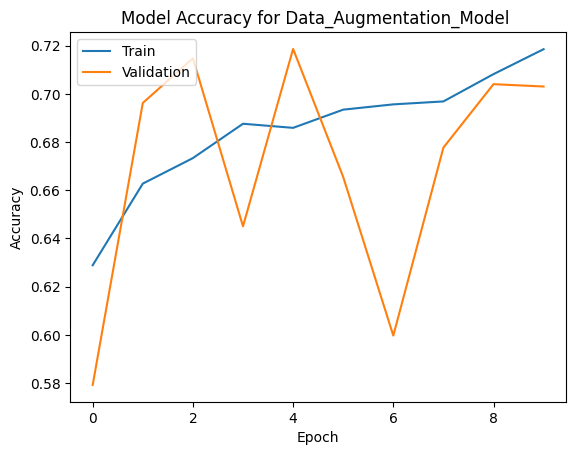

In [ ]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('Model Accuracy for Data_Augmentation_Model ')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
# Save the plot as an image file
plt.savefig('/content/drive/MyDrive/Images/Data_Augmentation_Model_Accuracy.png')
plt.show()

In [ ]:
# Save the model in HDF5 format
keras_file_path_1='/content/drive/MyDrive/saved_model_1.keras'
model_1.save(keras_file_path_1)


In [ ]:
#from tensorflow.keras.models import load_model
# Load the saved model
#cnn_model_loaded_1 = tf.keras.models.load_model(keras_file_path_1)

#cnn_model_loaded_1.summary()

In [ ]:
predictions_1 = model_1.predict(X_test_scaled_1)
predicted_classes_1 = (predictions_1 > 0.5).astype("int32")

36/36 [==============================] - 12s 325ms/step


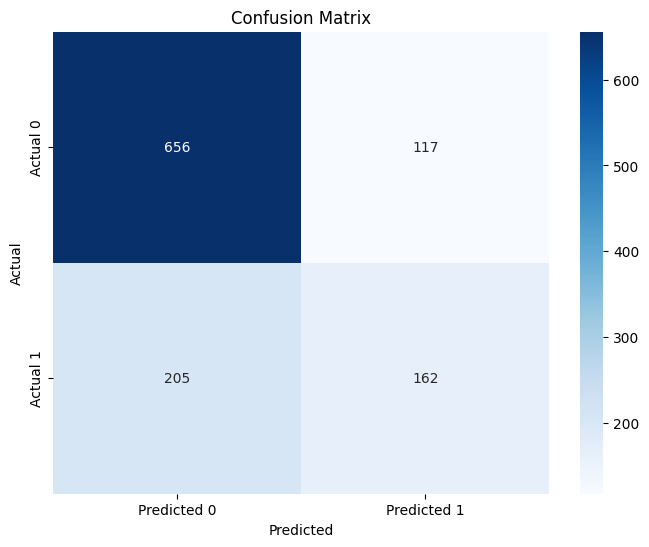

In [ ]:
#Plot the Confusion matrix
cm = confusion_matrix(Y_test_1, predicted_classes_1)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/Images/Data_Augmentation_Model_Confusion_Matrix.png')
plt.show()

In [ ]:
# Calculate accuracy
accuracy_1 = accuracy_score(Y_test_1, predicted_classes_1)
# Calculate precision
precision_1 = precision_score(Y_test_1, predicted_classes_1)
# Calculate recall
recall_1 = recall_score(Y_test_1, predicted_classes_1)
# Calculate F1 score
f1_1 = f1_score(Y_test_1, predicted_classes_1)
print(f'Results for the Data_Augmentation_Model')
print(f'Accuracy: {accuracy_1:.4f}')
print(f'Precision: {precision_1:.4f}')
print(f'Recall: {recall_1:.4f}')
print(f'F1 Score: {f1_1:.4f}')

Accuracy: 0.7175
Precision: 0.5806
Recall: 0.4414
F1 Score: 0.5015


In [ ]:
new_row_index = len(df_results)
df_results.loc[new_row_index] = ['Data_Augmentation_Model',accuracy,precision,recall,f1]
df_results

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,Base Model,0.6281,0.4417,0.5886,0.5047
1,Base_Model_with_l2,0.7281,0.5722,0.6158,0.5932
2,Data_Augmentation_Model,0.7175,0.5806,0.4414,0.5015


## Transfer Learning with rest of the dataset

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
checkpoint_path = '/content/drive/MyDrive/cnn_model_with_l2_checkpoint_after_transfer_learning.h5'

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
pretrained_model = load_model(checkpoint_path)

In [ ]:
pretrained_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 300, 300, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 150, 150, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 150, 150, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 75, 75, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 37, 37, 128)       0

In [ ]:
for layer in pretrained_model.layers:
    layer.trainable = False

In [ ]:
optimizer = tf.keras.optimizers.Adam(0.001)
pretrained_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-6
)

In [ ]:
checkpoint_path = '/content/drive/MyDrive/cnn_model_with_l2_final.h5'
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

In [ ]:
pretrained_model.fit(
    X_train_transformed,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_valid_transformed, np.array(y_valid)),
    callbacks=[checkpoint_callback, early_stopping, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/10
199/199 [==============================] - ETA: 0s - loss: 0.6823 - accuracy: 0.7427
Epoch 1: val_accuracy improved from -inf to 0.73126, saving model to /content/drive/MyDrive/cnn_model_with_l2_final.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


199/199 [==============================] - 33s 162ms/step - loss: 0.6823 - accuracy: 0.7427 - val_loss: 0.6468 - val_accuracy: 0.7313 - lr: 0.0010
Epoch 2/10
199/199 [==============================] - ETA: 0s - loss: 0.6858 - accuracy: 0.7408
Epoch 2: val_accuracy did not improve from 0.73126
199/199 [==============================] - 32s 159ms/step - loss: 0.6858 - accuracy: 0.7408 - val_loss: 0.6468 - val_accuracy: 0.7313 - lr: 0.0010
Epoch 3/10
199/199 [==============================] - ETA: 0s - loss: 0.6829 - accuracy: 0.7425
Epoch 3: val_accuracy did not improve from 0.73126
199/199 [==============================] - 32s 162ms/step - loss: 0.6829 - accuracy: 0.7425 - val_loss: 0.6468 - val_accuracy: 0.7313 - lr: 0.0010
Epoch 4/10
199/199 [==============================] - ETA: 0s - loss: 0.6848 - accuracy: 0.7413
Epoch 4: val_accuracy did not improve from 0.73126
199/199 [==============================] - 32s 163ms/step - loss: 0.6848 - accuracy: 0.7413 - val_loss: 0.6468 - val_a

In [ ]:
pickle_file_path='/content/drive/MyDrive/cnn_model_with_l2_final.pkl'
with open(pickle_file_path, 'wb') as file:
    pickle.dump(pretrained_model, file)

In [ ]:
history = pretrained_model.history

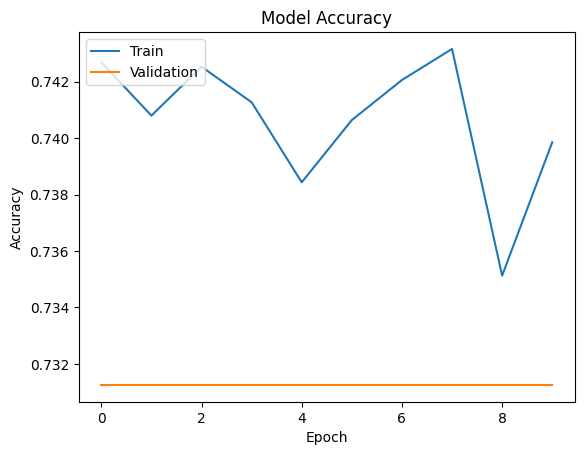

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('/content/drive/MyDrive/Images/Model_Accuracy_cnn_model_with_l2.png')
plt.show()

In [ ]:
predictions = pretrained_model.predict(X_valid_transformed)

predicted_classes = (predictions > 0.5).astype("int32")

23/23 [==============================] - 3s 144ms/step


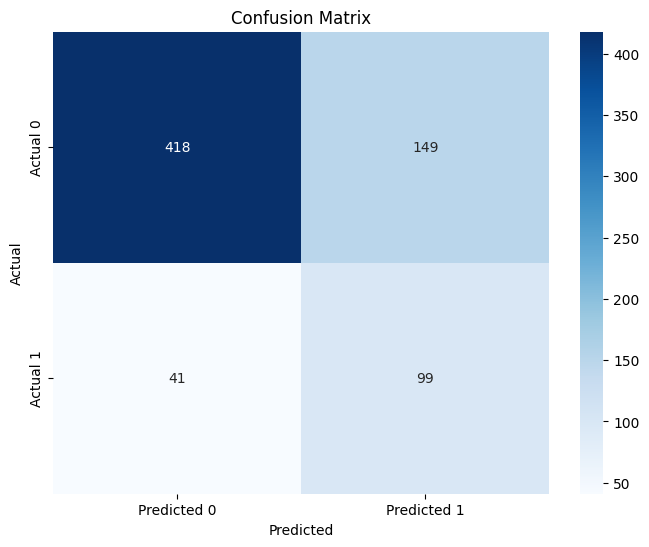

In [ ]:
cm = confusion_matrix(np.array(y_valid), predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/Images/Confusion_Matrix_cnn_model_with_l2.png')
plt.show()

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(np.array(y_valid), predicted_classes)

# Calculate precision
precision = precision_score(np.array(y_valid), predicted_classes)

# Calculate recall
recall = recall_score(np.array(y_valid), predicted_classes)

# Calculate F1 score
f1 = f1_score(np.array(y_valid), predicted_classes)

In [ ]:
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.7313
Precision: 0.3992
Recall: 0.7071
F1 Score: 0.5103


In [ ]:
new_row_index = len(df_results)
df_results.loc[new_row_index] = ['Transfer Learning with rest of the dataset',accuracy,precision,recall,f1]
df_results

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,Base Model,0.6281,0.4417,0.5886,0.5047
1,Base_Model_with_l2,0.7281,0.5722,0.6158,0.5932
2,Data_Augmentation_Model,0.7175,0.5806,0.4414,0.5015
3,Transfer Learning with rest of the dataset,0.7313,0.3992,0.7071,0.5103


## ResNet50

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

94765736/94765736 [==============================] - 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

In [ ]:
model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-6
)

In [ ]:
checkpoint_path = '/content/drive/MyDrive/ResNet50.h5'
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

In [ ]:
history = model.fit(
                X_train_rgb,
                y_train,
                epochs=10,
                batch_size=32,
                validation_data=(X_valid_rgb, np.array(y_val)),
                callbacks=[checkpoint_callback, early_stopping, reduce_lr],
                class_weight=class_weight_dict
            )

Epoch 1/10
676/676 [==============================] - ETA: 0s - loss: 0.6898 - accuracy: 0.5479
Epoch 1: val_accuracy improved from -inf to 0.50583, saving model to /content/drive/MyDrive/ResNet50.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


676/676 [==============================] - 408s 598ms/step - loss: 0.6898 - accuracy: 0.5479 - val_loss: 0.6951 - val_accuracy: 0.5058 - lr: 0.0010
Epoch 2/10
676/676 [==============================] - ETA: 0s - loss: 0.6649 - accuracy: 0.5882
Epoch 2: val_accuracy improved from 0.50583 to 0.56536, saving model to /content/drive/MyDrive/ResNet50.h5
676/676 [==============================] - 402s 594ms/step - loss: 0.6649 - accuracy: 0.5882 - val_loss: 0.6698 - val_accuracy: 0.5654 - lr: 0.0010
Epoch 3/10
676/676 [==============================] - ETA: 0s - loss: 0.6496 - accuracy: 0.6017
Epoch 3: val_accuracy did not improve from 0.56536
676/676 [==============================] - 411s 608ms/step - loss: 0.6496 - accuracy: 0.6017 - val_loss: 0.7684 - val_accuracy: 0.4538 - lr: 0.0010
Epoch 4/10
676/676 [==============================] - ETA: 0s - loss: 0.6485 - accuracy: 0.6069
Epoch 4: val_accuracy did not improve from 0.56536
676/676 [==============================] - 407s 603ms/step 

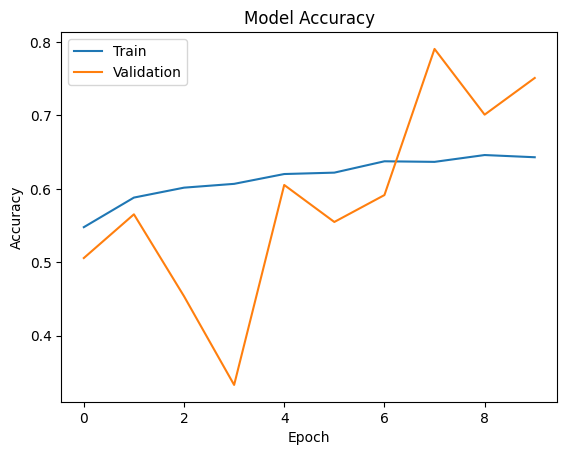

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('/content/drive/MyDrive/Images/Model_Accuracy_ResNet50.png')
plt.show()

In [ ]:
predictions = model.predict(X_test_rgb)

predicted_classes = (predictions > 0.5).astype("int32")

84/84 [==============================] - 46s 542ms/step


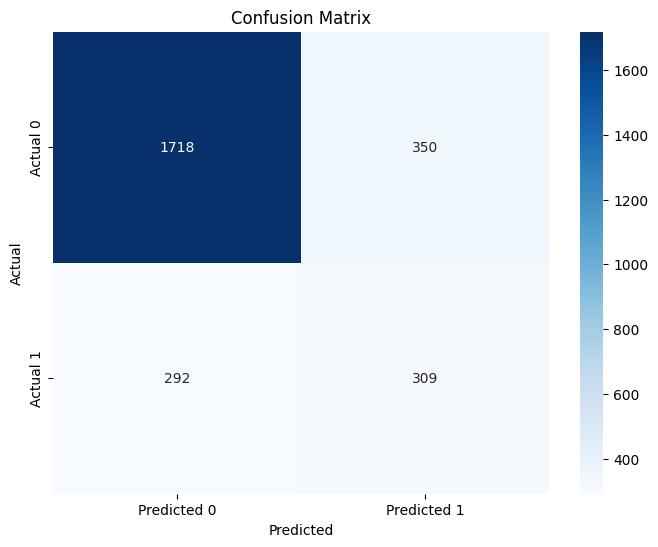

In [ ]:
cm = confusion_matrix(np.array(y_test), predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/Images/Confusion_Matrix_ResNet50.png')
plt.show()

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(np.array(y_test), predicted_classes)

# Calculate precision
precision = precision_score(np.array(y_test), predicted_classes)

# Calculate recall
recall = recall_score(np.array(y_test), predicted_classes)

# Calculate F1 score
f1 = f1_score(np.array(y_test), predicted_classes)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.7595
Precision: 0.4689
Recall: 0.5141
F1 Score: 0.4905


In [ ]:
new_row_index = len(df_results)
df_results.loc[new_row_index] = ['ResNet50',accuracy,precision,recall,f1]
df_results

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,Base Model,0.6281,0.4417,0.5886,0.5047
1,Base_Model_with_l2,0.7281,0.5722,0.6158,0.5932
2,Data_Augmentation_Model,0.7175,0.5806,0.4414,0.5015
3,Transfer Learning with rest of the dataset,0.7313,0.3992,0.7071,0.5103
4,ResNet50,0.7595,0.4689,0.5141,0.4905


## Fine_Tuned_ResNet50

In [ ]:
for layer in model.layers[-20:]:
    layer.trainable = True

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
checkpoint_path = '/content/drive/MyDrive/Fine_Tuned_ResNet50.h5'
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

In [ ]:
history = model.fit(
                X_train_rgb,
                y_train,
                epochs=10,
                batch_size=32,
                validation_data=(X_valid_rgb, np.array(y_val)),
                callbacks=[checkpoint_callback, early_stopping, reduce_lr],
                class_weight=class_weight_dict
            )

Epoch 1/10
676/676 [==============================] - ETA: 0s - loss: 0.6087 - accuracy: 0.6942
Epoch 1: val_accuracy improved from -inf to 0.60949, saving model to /content/drive/MyDrive/Fine_Tuned_ResNet50.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


676/676 [==============================] - 482s 707ms/step - loss: 0.6087 - accuracy: 0.6942 - val_loss: 0.6575 - val_accuracy: 0.6095 - lr: 1.0000e-05
Epoch 2/10
676/676 [==============================] - ETA: 0s - loss: 0.5740 - accuracy: 0.7032
Epoch 2: val_accuracy improved from 0.60949 to 0.62989, saving model to /content/drive/MyDrive/Fine_Tuned_ResNet50.h5
676/676 [==============================] - 486s 719ms/step - loss: 0.5740 - accuracy: 0.7032 - val_loss: 0.7168 - val_accuracy: 0.6299 - lr: 1.0000e-05
Epoch 3/10
676/676 [==============================] - ETA: 0s - loss: 0.5630 - accuracy: 0.7108
Epoch 3: val_accuracy improved from 0.62989 to 0.78393, saving model to /content/drive/MyDrive/Fine_Tuned_ResNet50.h5
676/676 [==============================] - 483s 714ms/step - loss: 0.5630 - accuracy: 0.7108 - val_loss: 0.4784 - val_accuracy: 0.7839 - lr: 1.0000e-05
Epoch 4/10
676/676 [==============================] - ETA: 0s - loss: 0.5568 - accuracy: 0.7183
Epoch 4: val_accurac

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('/content/drive/MyDrive/Images/Model_Accuracy_Fine_Tuned_ResNet50.png')
plt.show()

In [ ]:
predictions = model.predict(X_test_rgb)

predicted_classes = (predictions > 0.5).astype("int32")

In [ ]:
cm = confusion_matrix(np.array(y_test), predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/Images/Confusion_Matrix_Fine_Tuned_ResNet50.png')
plt.show()

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(np.array(y_test), predicted_classes)

# Calculate precision
precision = precision_score(np.array(y_test), predicted_classes)

# Calculate recall
recall = recall_score(np.array(y_test), predicted_classes)

# Calculate F1 score
f1 = f1_score(np.array(y_test), predicted_classes)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

In [ ]:
new_row_index = len(df_results)
df_results.loc[new_row_index] = ['Fine_Tuned_ResNet50',accuracy,precision,recall,f1]
df_results

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,Base Model,0.6281,0.4417,0.5886,0.5047
1,Base_Model_with_l2,0.7281,0.5722,0.6158,0.5932
2,Data_Augmentation_Model,0.7175,0.5806,0.4414,0.5015
3,Transfer Learning with rest of the dataset,0.7313,0.3992,0.7071,0.5103
4,ResNet50,0.7595,0.4689,0.5141,0.4905
5,Fine_Tuned_ResNet50,0.7595,0.5806,0.5141,0.5341


## DenseNet

In [ ]:
from tensorflow.keras.applications import DenseNet121

In [ ]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

29084464/29084464 [==============================] - 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

In [ ]:
densenet_model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
densenet_model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
check_path = '/content/drive/MyDrive/DenseNet.h5'

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
densenet_model = load_model(check_path)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-6
)

In [ ]:
checkpoint_path = '/content/drive/MyDrive/DenseNet.h5'
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

In [ ]:
history = densenet_model.fit(
                X_train_rgb,
                y_train,
                epochs=5,
                batch_size=32,
                validation_data=(X_valid_rgb, np.array(y_val)),
                callbacks=[checkpoint_callback, early_stopping, reduce_lr],
                class_weight=class_weight_dict
            )

Epoch 1/5
676/676 [==============================] - ETA: 0s - loss: 0.5193 - accuracy: 0.7387
Epoch 1: val_accuracy improved from -inf to 0.73272, saving model to /content/drive/MyDrive/DenseNet.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


676/676 [==============================] - 1892s 3s/step - loss: 0.5193 - accuracy: 0.7387 - val_loss: 0.5066 - val_accuracy: 0.7327 - lr: 0.0010
Epoch 2/5
676/676 [==============================] - ETA: 0s - loss: 0.5136 - accuracy: 0.7417
Epoch 2: val_accuracy did not improve from 0.73272
676/676 [==============================] - 1765s 3s/step - loss: 0.5136 - accuracy: 0.7417 - val_loss: 0.6573 - val_accuracy: 0.6490 - lr: 0.0010
Epoch 3/5
676/676 [==============================] - ETA: 0s - loss: 0.5121 - accuracy: 0.7432
Epoch 3: val_accuracy improved from 0.73272 to 0.80058, saving model to /content/drive/MyDrive/DenseNet.h5
676/676 [==============================] - 1759s 3s/step - loss: 0.5121 - accuracy: 0.7432 - val_loss: 0.4371 - val_accuracy: 0.8006 - lr: 0.0010
Epoch 4/5
676/676 [==============================] - ETA: 0s - loss: 0.5021 - accuracy: 0.7477
Epoch 4: val_accuracy did not improve from 0.80058
676/676 [==============================] - 1734s 3s/step - loss: 0.5

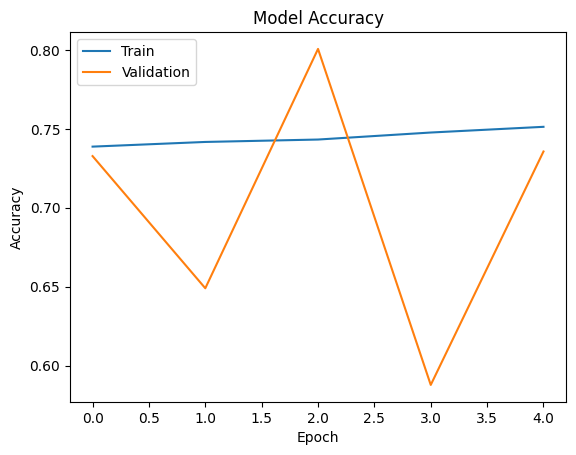

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('/content/drive/MyDrive/Images/Model_Accuracy_DenseNet.png')
plt.show()

In [ ]:
predictions = densenet_model.predict(X_test_rgb)

predicted_classes = (predictions > 0.5).astype("int32")

84/84 [==============================] - 37s 422ms/step


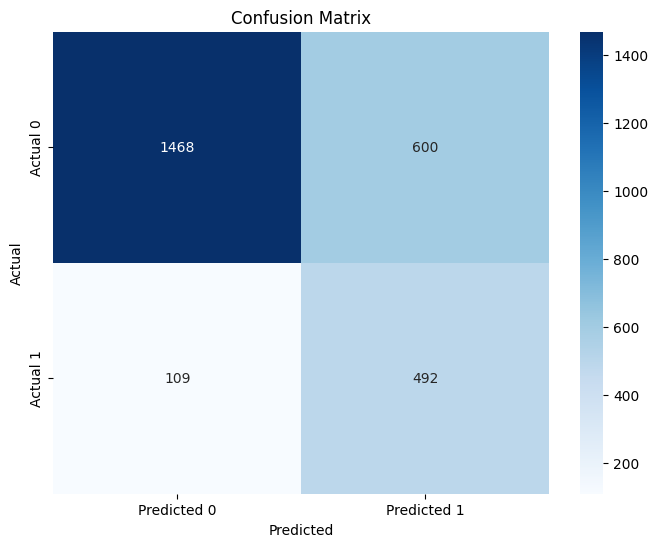

In [ ]:
cm = confusion_matrix(np.array(y_test), predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/Images/Confusion_Matrix_DenseNet.png')
plt.show()

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(np.array(y_test), predicted_classes)

# Calculate precision
precision = precision_score(np.array(y_test), predicted_classes)

# Calculate recall
recall = recall_score(np.array(y_test), predicted_classes)

# Calculate F1 score
f1 = f1_score(np.array(y_test), predicted_classes)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.7344
Precision: 0.4505
Recall: 0.8186
F1 Score: 0.5812


In [ ]:
new_row_index = len(df_results)
df_results.loc[new_row_index] = ['DenseNet',accuracy,precision,recall,f1]
df_results

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,Base Model,0.6281,0.4417,0.5886,0.5047
1,Base_Model_with_l2,0.7281,0.5722,0.6158,0.5932
2,Data_Augmentation_Model,0.7175,0.5806,0.4414,0.5015
3,Transfer Learning with rest of the dataset,0.7313,0.3992,0.7071,0.5103
4,ResNet50,0.7595,0.4689,0.5141,0.4905
5,Fine_Tuned_ResNet50,0.7595,0.5806,0.5141,0.5341
6,DenseNet,0.7344,0.4505,0.8186,0.5812


## Fine_Tuned_DenseNet

In [ ]:
!pip install tensorflow-addons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 2.7 MB/s eta 0:00:00


In [ ]:
import tensorflow_addons as tfa

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:
focal_loss = tfa.losses.SigmoidFocalCrossEntropy()

In [ ]:
densenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                       loss=focal_loss,
                       metrics=['accuracy'])

In [ ]:
checkpoint_path = '/content/drive/MyDrive/Fine_Tuned_DenseNet.h5'
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

In [ ]:
densenet_model = load_model(checkpoint_path)

In [ ]:
history = densenet_model.fit(
                X_train_rgb,
                y_train,
                epochs=4,
                batch_size=32,
                validation_data=(X_valid_rgb, np.array(y_val)),
                callbacks=[checkpoint_callback, early_stopping, reduce_lr],
                class_weight=class_weight_dict
            )

Epoch 1/4
676/676 [==============================] - ETA: 0s - loss: 0.0536 - accuracy: 0.8211
Epoch 1: val_accuracy improved from -inf to 0.81266, saving model to /content/drive/MyDrive/Fine_Tuned_DenseNet.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


676/676 [==============================] - 1918s 3s/step - loss: 0.0536 - accuracy: 0.8211 - val_loss: 0.0562 - val_accuracy: 0.8127 - lr: 0.0010
Epoch 2/4
676/676 [==============================] - ETA: 0s - loss: 0.0541 - accuracy: 0.8211
Epoch 2: val_accuracy improved from 0.81266 to 0.82806, saving model to /content/drive/MyDrive/Fine_Tuned_DenseNet.h5
676/676 [==============================] - 1826s 3s/step - loss: 0.0541 - accuracy: 0.8211 - val_loss: 0.0427 - val_accuracy: 0.8281 - lr: 0.0010
Epoch 3/4
 30/676 [>.............................] - ETA: 27:51 - loss: 0.0544 - accuracy: 0.8229

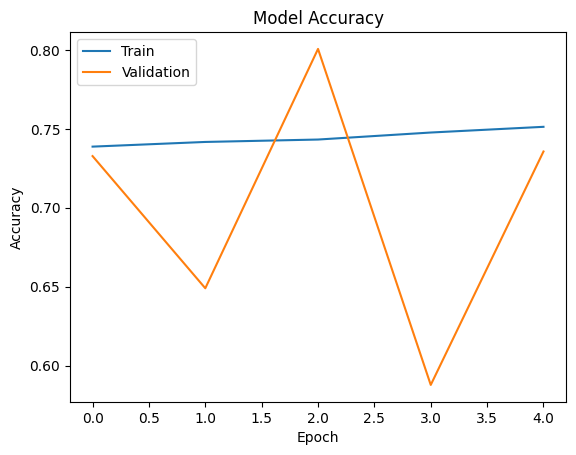

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('/content/drive/MyDrive/Images/Model_Accuracy_DenseNet.png')
plt.show()

In [ ]:
predictions = densenet_model.predict(X_test_rgb)

predicted_classes = (predictions > 0.5).astype("int32")

84/84 [==============================] - 37s 422ms/step


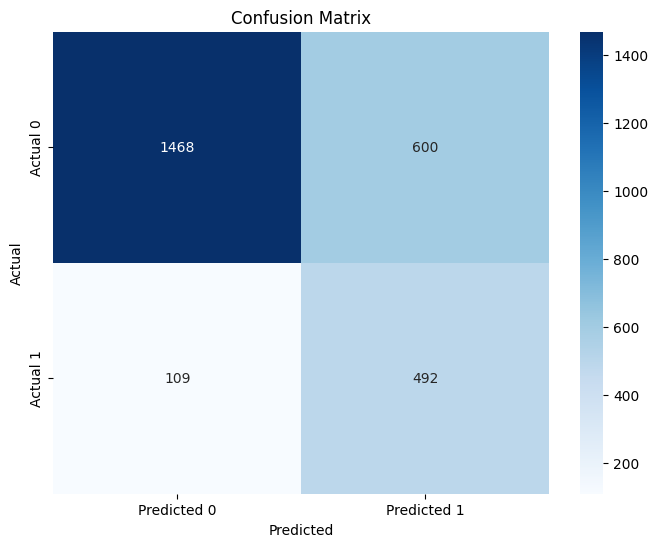

In [ ]:
cm = confusion_matrix(np.array(y_test), predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/Images/Confusion_Matrix_DenseNet.png')
plt.show()

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(np.array(y_test), predicted_classes)

# Calculate precision
precision = precision_score(np.array(y_test), predicted_classes)

# Calculate recall
recall = recall_score(np.array(y_test), predicted_classes)

# Calculate F1 score
f1 = f1_score(np.array(y_test), predicted_classes)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.7344
Precision: 0.4505
Recall: 0.8186
F1 Score: 0.5812


In [ ]:
new_row_index = len(df_results)
df_results.loc[new_row_index] = ['Fine_Tuned_DenseNet',accuracy,precision,recall,f1]
df_results

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,Base Model,0.6281,0.4417,0.5886,0.5047
1,Base_Model_with_l2,0.7281,0.5722,0.6158,0.5932
2,Data_Augmentation_Model,0.7175,0.5806,0.4414,0.5015
3,Transfer Learning with rest of the dataset,0.7313,0.3992,0.7071,0.5103
4,ResNet50,0.7595,0.4689,0.5141,0.4905
5,Fine_Tuned_ResNet50,0.7595,0.5806,0.5141,0.5341
6,DenseNet,0.7344,0.4505,0.8186,0.5812
7,Fine_Tuned_DenseNet,0.7344,0.4505,0.8186,0.5812


## R-CNN Model

In [ ]:
checkpoint_path = '/content/drive/MyDrive/Fine_Tuned_DenseNet.h5'

In [ ]:
base_model = load_model(checkpoint_path)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output

# Add Flatten layer
x = Flatten(name='flatten_output')(x)

# Add dense layers for object classification
classification_output = Dense(512, activation='relu', name='classification_dense_1')(x)
classification_output = Dense(1, activation='sigmoid', name='class_output')(classification_output)  # Binary classification

# Add dense layers for bounding box regression
bbox_output = Dense(512, activation='relu', name='bbox_dense_1')(x)
bbox_output = Dense(4, activation='linear', name='bbox_output')(bbox_output)

In [ ]:
rcnn_model = Model(inputs=base_model.input, outputs=[classification_output, bbox_output])

In [ ]:
rcnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'class_output': 'binary_crossentropy',
        'bbox_output': 'mean_squared_error'
    },
    metrics={
        'class_output': 'accuracy'
    }
)

In [ ]:
bbox_data = np.array(train_df['annotations'].apply(lambda x: [x[0]['x'], x[0]['y'], x[0]['width'], x[0]['height']]))

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-6
)

In [ ]:
checkpoint_path = '/content/drive/MyDrive/rcnn_model_checkpoint.h5'
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_class_output_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

In [ ]:
bbox_data = np.array(
    train_df['annotations'].apply(lambda x: [x[0]['x'], x[0]['y'], x[0]['width'], x[0]['height']]).tolist(),
    dtype=np.float32
)

validation_bbox_data = np.array(
    valid_df['annotations'].apply(lambda x: [x[0]['x'], x[0]['y'], x[0]['width'], x[0]['height']]).tolist(),
    dtype=np.float32
)

In [ ]:
X_train_rgb = np.array(X_train_rgb, dtype=np.float32)
X_valid_rgb = np.array(X_valid_rgb, dtype=np.float32)

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)

In [ ]:
history = rcnn_model.fit(
    X_train_rgb,
    {
        'class_output': y_train,
        'bbox_output': bbox_data
    },
    epochs=8,
    batch_size=32,
    validation_data=(
        X_valid_rgb,
        {
            'class_output': np.array(y_val),
            'bbox_output': validation_bbox_data
        }
    ),
    callbacks=[checkpoint_callback, early_stopping, reduce_lr]
)

Epoch 1/8
676/676 [==============================] - ETA: 0s - loss: nan - class_output_loss: 0.4265 - bbox_output_loss: nan - class_output_accuracy: 0.8049

676/676 [==============================] - 404s 597ms/step - loss: nan - class_output_loss: 0.4265 - bbox_output_loss: nan - class_output_accuracy: 0.8049 - val_loss: nan - val_class_output_loss: 0.3628 - val_bbox_output_loss: nan - val_class_output_accuracy: 0.8314 - lr: 0.0010
Epoch 2/8
676/676 [==============================] - ETA: 0s - loss: nan - class_output_loss: 0.3927 - bbox_output_loss: nan - class_output_accuracy: 0.8233

676/676 [==============================] - 402s 595ms/step - loss: nan - class_output_loss: 0.3927 - bbox_output_loss: nan - class_output_accuracy: 0.8233 - val_loss: nan - val_class_output_loss: 0.3614 - val_bbox_output_loss: nan - val_class_output_accuracy: 0.8326 - lr: 0.0010
Epoch 3/8
676/676 [==============================] - ETA: 0s - loss: nan - class_output_loss: 0.3931 - bbox_output_loss: nan - class_output_accuracy: 0.8194

676/676 [==============================] - 402s 595ms/step - loss: nan - class_output_loss: 0.3931 - bbox_output_loss: nan - class_output_accuracy: 0.8194 - val_loss: nan - val_class_output_loss: 0.3620 - val_bbox_output_loss: nan - val_class_output_accuracy: 0.8339 - lr: 0.0010
Epoch 4/8
676/676 [==============================] - ETA: 0s - loss: nan - class_output_loss: 0.3901 - bbox_output_loss: nan - class_output_accuracy: 0.8250

676/676 [==============================] - 401s 594ms/step - loss: nan - class_output_loss: 0.3901 - bbox_output_loss: nan - class_output_accuracy: 0.8250 - val_loss: nan - val_class_output_loss: 0.3620 - val_bbox_output_loss: nan - val_class_output_accuracy: 0.8281 - lr: 1.0000e-04
Epoch 5/8
676/676 [==============================] - ETA: 0s - loss: nan - class_output_loss: 0.3899 - bbox_output_loss: nan - class_output_accuracy: 0.8241

676/676 [==============================] - 397s 587ms/step - loss: nan - class_output_loss: 0.3899 - bbox_output_loss: nan - class_output_accuracy: 0.8241 - val_loss: nan - val_class_output_loss: 0.3609 - val_bbox_output_loss: nan - val_class_output_accuracy: 0.8326 - lr: 1.0000e-04
Epoch 6/8
676/676 [==============================] - ETA: 0s - loss: nan - class_output_loss: 0.3904 - bbox_output_loss: nan - class_output_accuracy: 0.8225

676/676 [==============================] - 382s 565ms/step - loss: nan - class_output_loss: 0.3904 - bbox_output_loss: nan - class_output_accuracy: 0.8225 - val_loss: nan - val_class_output_loss: 0.3611 - val_bbox_output_loss: nan - val_class_output_accuracy: 0.8322 - lr: 1.0000e-04
Epoch 7/8
676/676 [==============================] - ETA: 0s - loss: nan - class_output_loss: 0.3893 - bbox_output_loss: nan - class_output_accuracy: 0.8244

676/676 [==============================] - 387s 572ms/step - loss: nan - class_output_loss: 0.3893 - bbox_output_loss: nan - class_output_accuracy: 0.8244 - val_loss: nan - val_class_output_loss: 0.3611 - val_bbox_output_loss: nan - val_class_output_accuracy: 0.8326 - lr: 1.0000e-05
Epoch 8/8
676/676 [==============================] - ETA: 0s - loss: nan - class_output_loss: 0.3909 - bbox_output_loss: nan - class_output_accuracy: 0.8220

676/676 [==============================] - 397s 587ms/step - loss: nan - class_output_loss: 0.3909 - bbox_output_loss: nan - class_output_accuracy: 0.8220 - val_loss: nan - val_class_output_loss: 0.3611 - val_bbox_output_loss: nan - val_class_output_accuracy: 0.8326 - lr: 1.0000e-05


In [ ]:
rcnn_model.save('/content/drive/MyDrive/RCNN_Model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
X_test_rgb = np.array(X_test_rgb, dtype=np.float32)

In [ ]:
test_bbox_data = np.array(
    test_df['annotations'].apply(lambda x: [x[0]['x'], x[0]['y'], x[0]['width'], x[0]['height']]).tolist(),
    dtype=np.float32
)

In [ ]:
y_test = np.array(test_df['Target'], dtype=np.float32)

In [ ]:
results = rcnn_model.evaluate(X_test_rgb, {
    'class_output': y_test,
    'bbox_output': test_bbox_data
})

print(f"Test Loss: {results[0]:.4f}")
print(f"Test Classification Accuracy: {results[3]:.4f}")

84/84 [==============================] - 43s 513ms/step - loss: nan - class_output_loss: 0.3771 - bbox_output_loss: nan - class_output_accuracy: 0.8314
Test Loss: nan
Test Classification Accuracy: 0.8314


In [ ]:
classification_preds, bbox_preds = rcnn_model.predict(X_test_rgb)

84/84 [==============================] - 49s 519ms/step


In [ ]:
new_row_index = len(df_results)
df_results.loc[new_row_index] = ['R-CNN Model',accuracy,precision,recall,f1]
df_results

,Model_Name,Accuracy,Precision,Recall,F1_Score
0,Base Model,0.6281,0.4417,0.5886,0.5047
1,Base_Model_with_l2,0.7281,0.5722,0.6158,0.5932
2,Data_Augmentation_Model,0.7175,0.5806,0.4414,0.5015
3,Transfer Learning with rest of the dataset,0.7313,0.3992,0.7071,0.5103
4,ResNet50,0.7595,0.4689,0.5141,0.4905
5,Fine_Tuned_ResNet50,0.7595,0.5806,0.5141,0.5341
6,DenseNet,0.7344,0.4505,0.8186,0.5812
7,Fine_Tuned_DenseNet,0.7344,0.4505,0.8186,0.5812
8,R-CNN Model,0.7544,0.4705,0.8186,0.6012


## MaskRCNN Model

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

In [ ]:
weights = MaskRCNN_ResNet50_FPN_Weights.COCO_V1
model = maskrcnn_resnet50_fpn(weights=weights)
num_classes = 2  # Background and pneumonia

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
num_epochs = 10
best_val_loss = float('inf')
for epoch in range(num_epochs):
    model.train()
    for images, targets in train_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        losses.backward()
        optimizer.step()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            val_loss += sum(loss for loss in loss_dict.values()).item()

    val_loss /= len(val_loader)
    print(f"Epoch {epoch + 1}, Validation Loss: {val_loss}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_mask_rcnn_model.h5')
        print(f"Model saved with validation loss: {val_loss}")

## Explanation for Mask R-CNN Model Running Time and Resource Limitations
We have been attempting to train the Mask R-CNN model for the Pneumonia Detection Challenge, but the process has faced significant interruptions due to resource constraints, particularly with memory and computational power. Below is a detailed explanation of the challenges and why these issues arise:

#### Complexity of Mask R-CNN Architecture
* `Model Size:` Mask R-CNN is a large and computationally intensive model. It not only performs object detection (bounding box predictions) but also instance segmentation (generating pixel-level masks), which requires a significant amount of GPU memory and processing power.

* `ResNet50 Backbone:` The backbone network used (ResNet50 with Feature Pyramid Networks) involves multiple layers of convolutional operations at different resolutions, making the model particularly heavy to train.

#### DICOM Image Dataset
* `High-Resolution Images:` The DICOM images in the pneumonia dataset are often high-resolution, which increases the memory and computational load. Processing large images requires more memory, especially when applying augmentations, and the model needs to perform multiple convolutional operations on these high-dimensional inputs.

#### Resource Limitations
* `Memory Overflow:` The GPU memory allocated for training is often insufficient to handle the model’s requirements. The size of the model, combined with the image data and batch size, can lead to memory overflow, causing training jobs to be interrupted prematurely.

* `Training Time:` Mask R-CNN involves multiple processes (classification, bounding box regression, mask generation) that are computationally expensive. As a result, the model takes significantly longer to train compared to simpler CNN-based models.


### `The Mask R-CNN model is highly resource-intensive, and our current system's memory and computational capacity are not sufficient to handle the training process efficiently. This is resulting in prolonged training times and job interruptions.`